# Model Development và Credit Scorecard

Notebook này bắt đầu **sau khi Feature Selection đã hoàn tất**.

Mục tiêu:

1. Đọc lại các artifact đã được tạo từ notebook Feature Selection.
2. So sánh ba cấu trúc biến bằng cùng một hệ thống cross-validation trên tập train.
3. Chọn cấu trúc cuối cùng theo prediction timestamp và hiệu năng ngoài mẫu.
4. Fit mô hình logistic cuối cùng trên toàn bộ tập train.
5. Đánh giá đúng một lần trên tập test.
6. Chuyển xác suất vỡ nợ và odds thành Credit Score.
7. Tạo bảng điểm theo từng bin và kiểm tra bad rate theo score band.



In [1]:
!pip install -q openpyxl joblib statsmodels scikit-learn

# Bước 1 — Import thư viện

Các thư viện được chia thành bốn nhóm:

- Xử lý dữ liệu: `numpy`, `pandas`.
- Mô hình thống kê: `statsmodels`.
- Đánh giá mô hình: `scikit-learn`.
- Lưu artifact: `joblib`, `json`.

In [2]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    brier_score_loss,
    log_loss
)
from sklearn.model_selection import StratifiedKFold
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

# Bước 2 — Mount Google Drive và cấu hình đường dẫn

Notebook đọc các artifact từ thư mục đầu ra của Feature Selection.

`FS_ARTIFACT_DIR` phải trùng với `OUTPUT_DIR` ở cuối notebook Feature Selection.

In [3]:
from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False
)

Mounted at /content/drive


In [4]:
# ============================================================
# CẤU HÌNH CHUNG
# ============================================================

TARGET = "loan_status"
RANDOM_STATE = 42
N_SPLITS = 10
VIF_THRESHOLD = 5.0

# Mô hình được sử dụng trước khi grade và lãi suất được xác định.
PREDICTION_CONTEXT = "pre_decision"

FS_ARTIFACT_DIR = Path(
    "/content/drive/MyDrive/"
    "AIO 2026/Conquer/Data/"
    "train_test_feature_selection/"
    "explainable_feature_selection"
)

MODEL_OUTPUT_DIR = Path(
    "/content/drive/MyDrive/"
    "AIO 2026/Conquer/Data/"
    "train_test_feature_selection/"
    "model_development_scorecard"
)

MODEL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Feature Selection artifacts:")
print(FS_ARTIFACT_DIR)

print("\nModel outputs:")
print(MODEL_OUTPUT_DIR)

Feature Selection artifacts:
/content/drive/MyDrive/AIO 2026/Conquer/Data/train_test_feature_selection/explainable_feature_selection

Model outputs:
/content/drive/MyDrive/AIO 2026/Conquer/Data/train_test_feature_selection/model_development_scorecard


# Bước 3 — Đọc các file từ Feature Selection

Các file bắt buộc:

```text
train_woe_dataset.csv
test_woe_dataset.csv
train_bin_dataset.csv
test_bin_dataset.csv
cleaned_binning_tables.joblib
binning_tables.joblib
model_feature_sets.json
```

Tập test chỉ được đọc để chuẩn bị pipeline. Việc chọn cấu trúc mô hình vẫn dựa hoàn toàn trên cross-validation của tập train.

In [5]:
REQUIRED_FILES = [
    "train_woe_dataset.csv",
    "test_woe_dataset.csv",
    "train_bin_dataset.csv",
    "test_bin_dataset.csv",
    "cleaned_binning_tables.joblib",
    "binning_tables.joblib",
    "model_feature_sets.json"
]

missing_files = [
    filename
    for filename in REQUIRED_FILES
    if not (FS_ARTIFACT_DIR / filename).exists()
]

if missing_files:
    raise FileNotFoundError(
        "Thiếu artifact từ Feature Selection: "
        f"{missing_files}\n"
        "Hãy chạy hai cell xuất artifact ở cuối notebook "
        "FS_credit_score_completed_export.ipynb."
    )

In [6]:
train_woe_dataset = pd.read_csv(
    FS_ARTIFACT_DIR / "train_woe_dataset.csv",
    index_col="original_index"
)

test_woe_dataset = pd.read_csv(
    FS_ARTIFACT_DIR / "test_woe_dataset.csv",
    index_col="original_index"
)

train_bin_dataset = pd.read_csv(
    FS_ARTIFACT_DIR / "train_bin_dataset.csv",
    index_col="original_index"
)

test_bin_dataset = pd.read_csv(
    FS_ARTIFACT_DIR / "test_bin_dataset.csv",
    index_col="original_index"
)

cleaned_binning_tables = joblib.load(
    FS_ARTIFACT_DIR / "cleaned_binning_tables.joblib"
)

binning_tables = joblib.load(
    FS_ARTIFACT_DIR / "binning_tables.joblib"
)

with open(
    FS_ARTIFACT_DIR / "model_feature_sets.json",
    "r",
    encoding="utf-8"
) as file:
    feature_selection_metadata = json.load(file)

print("Train WOE shape:", train_woe_dataset.shape)
print("Test WOE shape :", test_woe_dataset.shape)
print("Train default rate:", f"{train_woe_dataset[TARGET].mean():.2%}")
print("Test default rate :", f"{test_woe_dataset[TARGET].mean():.2%}")

Train WOE shape: (25343, 12)
Test WOE shape : (6336, 12)
Train default rate: 21.54%
Test default rate : 21.54%


# Bước 4 — Khai báo ba cấu trúc mô hình

Ba cấu trúc được so sánh:

### Model 1 — IV-screened full

Giữ toàn bộ biến vượt qua IV screening. Đây là benchmark hoặc mô hình post-decision.

### Intermediate — Pre-decision full financial

Loại `loan_grade` và `loan_int_rate`, nhưng vẫn giữ `person_income` và `loan_amnt`.

Cấu trúc này giúp đo riêng chi phí của việc loại các biến hậu quyết định.

### Model 2 — Explainable pre-decision

Loại grade, lãi suất, thu nhập và số tiền vay; chỉ giữ `loan_percent_income` trong nhóm ba biến tài chính liên quan.

Cấu trúc này ưu tiên tính gọn và khả năng giải thích.

In [7]:
stored_feature_sets = feature_selection_metadata[
    "model_feature_sets"
]

MODEL_1_FEATURES = stored_feature_sets[
    "model_1_iv_screened_full"
]

MODEL_2_FEATURES = stored_feature_sets[
    "model_2_explainable_predecision"
]

MODEL_INTERMEDIATE_FEATURES = stored_feature_sets.get(
    "model_intermediate_predecision_full_financial",
    [
        feature
        for feature in MODEL_1_FEATURES
        if feature not in [
            "loan_grade",
            "loan_int_rate"
        ]
    ]
)

CANDIDATE_FEATURE_SETS = {
    "model_1_iv_screened_full": MODEL_1_FEATURES,
    "model_intermediate_predecision_full_financial": (
        MODEL_INTERMEDIATE_FEATURES
    ),
    "model_2_explainable_predecision": MODEL_2_FEATURES
}

MODEL_LABELS = {
    "model_1_iv_screened_full": (
        "Model 1 — IV-screened full"
    ),
    "model_intermediate_predecision_full_financial": (
        "Intermediate — Pre-decision full financial"
    ),
    "model_2_explainable_predecision": (
        "Model 2 — Explainable pre-decision"
    )
}

available_features = set(
    train_woe_dataset.columns
) - {TARGET}

for model_key, features in CANDIDATE_FEATURE_SETS.items():
    missing = sorted(
        set(features) - available_features
    )

    if missing:
        raise KeyError(
            f"{model_key} thiếu các biến: {missing}"
        )

feature_set_table = pd.DataFrame([
    {
        "Model key": model_key,
        "Model": MODEL_LABELS[model_key],
        "Number of features": len(features),
        "Features": " | ".join(features)
    }
    for model_key, features
    in CANDIDATE_FEATURE_SETS.items()
])

display(feature_set_table)

,Model key,Model,Number of features,Features
0,model_1_iv_screened_full,Model 1 — IV-screened full,9,person_income | person_home_ownership | person_emp_length | loan_intent | loan_grade | loan_amnt | loan_int_rate | l...
1,model_intermediate_predecision_full_financial,Intermediate — Pre-decision full financial,7,person_income | person_home_ownership | person_emp_length | loan_intent | loan_amnt | loan_percent_income | cb_perso...
2,model_2_explainable_predecision,Model 2 — Explainable pre-decision,5,person_home_ownership | person_emp_length | loan_intent | loan_percent_income | cb_person_default_on_file


## Nhận xét ba cấu trúc mô hình

Ba cấu trúc được xây dựng để trả lời ba câu hỏi khác nhau:

| Cấu trúc | Số biến | Vai trò |
|---|---:|---|
| Model 1 — IV-screened full | 9 | Benchmark, sử dụng cả grade và lãi suất |
| Intermediate — Pre-decision full financial | 7 | Pre-decision, giữ thông tin thu nhập và khoản vay |
| Model 2 — Explainable pre-decision | 5 | Pre-decision gọn, chỉ giữ tỷ lệ khoản vay trên thu nhập |



Cấu trúc Intermediate và Model 2 đều phù hợp với prediction timestamp pre-decision. Điểm khác nhau giữa hai cấu trúc là quyết định có giữ `person_income` và `loan_amnt` hay không.

### Quyết định

- Giữ Model 1 làm benchmark để đo lượng thông tin bị mất do ràng buộc nghiệp vụ.
- Chỉ lựa chọn mô hình triển khai giữa Intermediate và Model 2.
- Không dùng tập test để quyết định giữa hai cấu trúc pre-decision.

# Bước 5 — Hàm đánh giá mô hình trên train

Mỗi cấu trúc được đánh giá bằng cùng một hệ thống 10-fold stratified cross-validation.

Các chỉ tiêu:

$$
Gini=2AUC-1.
$$

$$
Brier
=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat p_i)^2.
$$

Ngoài ra, notebook tính:

- Log loss.
- Kolmogorov–Smirnov statistic.
- Calibration intercept và slope.
- Maximum VIF.
- Độ ổn định của hệ số qua các folds.

Mô hình trong mỗi fold là logistic regression không penalty, fit bằng `statsmodels.GLM`.

In [8]:
def calculate_vif(X):
    X = X.astype(float).copy()

    if X.shape[1] == 1:
        return pd.DataFrame({
            "Variable": X.columns,
            "VIF": [1.0]
        })

    X_constant = sm.add_constant(
        X,
        has_constant="add"
    )

    rows = []

    for column_index, variable in enumerate(
        X_constant.columns
    ):
        if variable == "const":
            continue

        try:
            vif_value = variance_inflation_factor(
                X_constant.values,
                column_index
            )
        except Exception:
            vif_value = np.inf

        rows.append({
            "Variable": variable,
            "VIF": float(vif_value)
        })

    return (
        pd.DataFrame(rows)
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )


def calculate_ks(y_true, probability):
    fpr, tpr, _ = roc_curve(
        y_true,
        probability
    )

    return float(
        np.max(tpr - fpr)
    )


def calculate_calibration(
    y_true,
    probability
):
    probability = np.clip(
        np.asarray(probability, dtype=float),
        1e-8,
        1 - 1e-8
    )

    predicted_logit = np.log(
        probability / (1 - probability)
    )

    calibration_X = sm.add_constant(
        predicted_logit,
        has_constant="add"
    )

    calibration_model = sm.GLM(
        np.asarray(y_true, dtype=int),
        calibration_X,
        family=sm.families.Binomial()
    ).fit()

    return {
        "Calibration intercept": float(
            calibration_model.params[0]
        ),
        "Calibration slope": float(
            calibration_model.params[1]
        )
    }

In [9]:
def evaluate_feature_set_cv(
    data,
    target,
    features,
    model_key,
    model_label,
    cv_splits
):
    X = data[features].astype(float)
    y = data[target].astype(int)

    oof_probability = np.full(
        len(data),
        np.nan,
        dtype=float
    )

    fold_metrics = []
    coefficient_rows = []

    for fold_number, (
        train_index,
        valid_index
    ) in enumerate(cv_splits, start=1):

        X_fold_train = sm.add_constant(
            X.iloc[train_index],
            has_constant="add"
        )

        X_fold_valid = sm.add_constant(
            X.iloc[valid_index],
            has_constant="add"
        )

        y_fold_train = y.iloc[train_index]
        y_fold_valid = y.iloc[valid_index]

        fold_model = sm.GLM(
            y_fold_train,
            X_fold_train,
            family=sm.families.Binomial()
        ).fit()

        fold_probability = np.asarray(
            fold_model.predict(X_fold_valid),
            dtype=float
        )

        oof_probability[
            valid_index
        ] = fold_probability

        fold_auc = roc_auc_score(
            y_fold_valid,
            fold_probability
        )

        fold_metrics.append({
            "Model key": model_key,
            "Model": model_label,
            "Fold": fold_number,
            "AUC": float(fold_auc),
            "Gini": float(2 * fold_auc - 1),
            "Brier": float(
                brier_score_loss(
                    y_fold_valid,
                    fold_probability
                )
            ),
            "Log loss": float(
                log_loss(
                    y_fold_valid,
                    fold_probability
                )
            ),
            "KS": calculate_ks(
                y_fold_valid,
                fold_probability
            )
        })

        for variable, coefficient in (
            fold_model.params.items()
        ):
            if variable == "const":
                continue

            coefficient_rows.append({
                "Model key": model_key,
                "Model": model_label,
                "Fold": fold_number,
                "Variable": variable,
                "Coefficient": float(coefficient),
                "Negative coefficient": bool(
                    coefficient < 0
                )
            })

    if np.isnan(oof_probability).any():
        raise RuntimeError(
            f"{model_label}: OOF prediction chưa đầy đủ."
        )

    fold_metrics_table = pd.DataFrame(
        fold_metrics
    )

    pooled_auc = roc_auc_score(
        y,
        oof_probability
    )

    calibration = calculate_calibration(
        y_true=y,
        probability=oof_probability
    )

    vif_table = calculate_vif(
        X
    )

    summary = {
        "Model key": model_key,
        "Model": model_label,
        "Number of features": len(features),
        "OOF AUC": float(pooled_auc),
        "OOF Gini": float(2 * pooled_auc - 1),
        "OOF Brier": float(
            brier_score_loss(
                y,
                oof_probability
            )
        ),
        "OOF Log loss": float(
            log_loss(
                y,
                oof_probability
            )
        ),
        "OOF KS": calculate_ks(
            y,
            oof_probability
        ),
        "Mean CV AUC": float(
            fold_metrics_table["AUC"].mean()
        ),
        "SD CV AUC": float(
            fold_metrics_table["AUC"].std(ddof=1)
        ),
        "SE CV AUC": float(
            fold_metrics_table["AUC"].std(ddof=1)
            / np.sqrt(len(fold_metrics_table))
        ),
        "Minimum fold AUC": float(
            fold_metrics_table["AUC"].min()
        ),
        "Maximum fold AUC": float(
            fold_metrics_table["AUC"].max()
        ),
        "Maximum VIF": float(
            vif_table["VIF"].max()
        ),
        "Any VIF > 5": bool(
            (vif_table["VIF"] > VIF_THRESHOLD).any()
        ),
        **calibration
    }

    coefficient_table = pd.DataFrame(
        coefficient_rows
    )

    coefficient_stability = (
        coefficient_table
        .groupby(
            [
                "Model key",
                "Model",
                "Variable"
            ],
            as_index=False
        )
        .agg(
            Mean_coefficient=(
                "Coefficient",
                "mean"
            ),
            SD_coefficient=(
                "Coefficient",
                "std"
            ),
            Negative_fold_rate=(
                "Negative coefficient",
                "mean"
            )
        )
    )

    return {
        "summary": summary,
        "oof_probability": oof_probability,
        "fold_metrics": fold_metrics_table,
        "vif": vif_table,
        "fold_coefficients": coefficient_table,
        "coefficient_stability": coefficient_stability
    }

# Bước 7 — Chạy cross-validation

Ba mô hình phải sử dụng đúng cùng một danh sách folds để chênh lệch hiệu năng không bị ảnh hưởng bởi cách chia mẫu.

In [10]:
y_train = (
    train_woe_dataset[TARGET]
    .astype(int)
)

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

CV_SPLITS = list(
    cv.split(
        train_woe_dataset,
        y_train
    )
)

candidate_results = {}

for model_key, features in (
    CANDIDATE_FEATURE_SETS.items()
):
    candidate_results[model_key] = (
        evaluate_feature_set_cv(
            data=train_woe_dataset,
            target=TARGET,
            features=features,
            model_key=model_key,
            model_label=MODEL_LABELS[model_key],
            cv_splits=CV_SPLITS
        )
    )

candidate_comparison = pd.DataFrame([
    result["summary"]
    for result in candidate_results.values()
])

candidate_comparison = (
    candidate_comparison
    .sort_values(
        "Mean CV AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    candidate_comparison.style.format({
        "OOF AUC": "{:.5f}",
        "OOF Gini": "{:.5f}",
        "OOF Brier": "{:.5f}",
        "OOF Log loss": "{:.5f}",
        "OOF KS": "{:.5f}",
        "Mean CV AUC": "{:.5f}",
        "SD CV AUC": "{:.5f}",
        "SE CV AUC": "{:.5f}",
        "Minimum fold AUC": "{:.5f}",
        "Maximum fold AUC": "{:.5f}",
        "Maximum VIF": "{:.4f}",
        "Calibration intercept": "{:.4f}",
        "Calibration slope": "{:.4f}"
    })
)

,Model key,Model,Number of features,OOF AUC,OOF Gini,OOF Brier,OOF Log loss,OOF KS,Mean CV AUC,SD CV AUC,SE CV AUC,Minimum fold AUC,Maximum fold AUC,Maximum VIF,Any VIF > 5,Calibration intercept,Calibration slope
0,model_1_iv_screened_full,Model 1 — IV-screened full,9,0.88270,0.76540,0.09344,0.31837,0.63153,0.88278,0.01099,0.00347,0.86716,0.90706,4.2209,False,-0.0027,0.9971
1,model_intermediate_predecision_full_financial,Intermediate — Pre-decision full financial,7,0.82573,0.65146,0.11465,0.37642,0.48821,0.82574,0.01233,0.00390,0.80704,0.84409,1.6191,False,-0.0021,0.9979
2,model_2_explainable_predecision,Model 2 — Explainable pre-decision,5,0.80575,0.61150,0.11811,0.38774,0.45227,0.80579,0.01068,0.00338,0.78873,0.82258,1.0580,False,-0.0014,0.9986


## Cách đọc bảng so sánh

Thứ tự đọc kết quả:

1. **Prediction timestamp:** loại các mô hình không hợp lệ về thời điểm sử dụng.
2. **AUC, Gini và KS:** càng cao càng tốt.
3. **Brier và log loss:** càng thấp càng tốt.
4. **Calibration intercept:** nên gần 0.
5. **Calibration slope:** nên gần 1.
6. **VIF:** không nên vượt 5.
7. **Số biến:** khi hiệu năng gần tương đương, ưu tiên cấu trúc gọn hơn.

Không sử dụng test AUC để chọn cấu trúc mô hình.

## Nhận xét kết quả so sánh mô hình trên train

### 1. Model 1 có khả năng phân biệt cao nhất

Model 1 đạt:

$$
OOF\ AUC=0.88270,\qquad
OOF\ Gini=0.76540,\qquad
OOF\ KS=0.63153.
$$

Tuy nhiên, Model 1 sử dụng `loan_grade` và `loan_int_rate`, nên không hợp lệ trong bối cảnh pre-decision. Kết quả của Model 1 được sử dụng như **benchmark**, không phải ứng viên triển khai.

Khi chuyển từ Model 1 sang cấu trúc Intermediate:

$$
\Delta AUC=-0.05697,
$$

$$
\Delta Gini=-0.11394,
$$

$$
\Delta KS=-0.14332.
$$

Đây là chi phí dự báo của việc loại grade và lãi suất khỏi mô hình.

### 2. Intermediate tốt hơn Model 2

Cấu trúc Intermediate đạt:

$$
OOF\ AUC=0.82573,\qquad
OOF\ Gini=0.65146.
$$

Model 2 đạt:

$$
OOF\ AUC=0.80575,\qquad
OOF\ Gini=0.61150.
$$

Khi loại thêm `person_income` và `loan_amnt`:

$$
\Delta AUC=-0.01998,
$$

$$
\Delta Gini=-0.03996,
$$

đồng thời Brier score tăng từ 0.11465 lên 0.11811 và log loss tăng từ 0.37642 lên 0.38774.

Như vậy, `person_income` và `loan_amnt` vẫn cung cấp thông tin dự báo bổ sung ngoài `loan_percent_income`. Chỉ giữ biến tỷ lệ giúp mô hình gọn hơn nhưng gây suy giảm khả năng phân biệt.

### 3. Đa cộng tuyến không phải lý do để loại hai biến tài chính

Maximum VIF của cấu trúc Intermediate chỉ bằng:

$$
1.6191<5.
$$

Model 2 có maximum VIF bằng 1.0580, nhưng sự cải thiện VIF này không bù lại mức giảm AUC, Gini và KS. Cả hai cấu trúc đều không có vấn đề đa cộng tuyến đáng kể.

### 4. Calibration OOF của cả ba cấu trúc đều tốt

Calibration intercept đều gần 0 và calibration slope đều gần 1. Điều này cho thấy xác suất OOF không xuất hiện dấu hiệu sai lệch tổng thể.

### Quyết định

- Loại Model 1 khỏi nhóm mô hình đủ điều kiện triển khai pre-decision.
- Không chọn Model 2 chỉ vì ít biến và VIF thấp hơn.
- Giữ cấu trúc Intermediate làm ứng viên chính vì nó cải thiện rõ khả năng phân biệt trong khi vẫn đáp ứng prediction timestamp và VIF thấp.

# Bước 8 — Trực quan hóa kết quả Model Comparison

Các biểu đồ dưới đây chỉ sử dụng out-of-fold prediction trên tập train.

Chúng hỗ trợ so sánh:

- Khả năng phân biệt.
- Sai số xác suất.
- Số lượng biến.

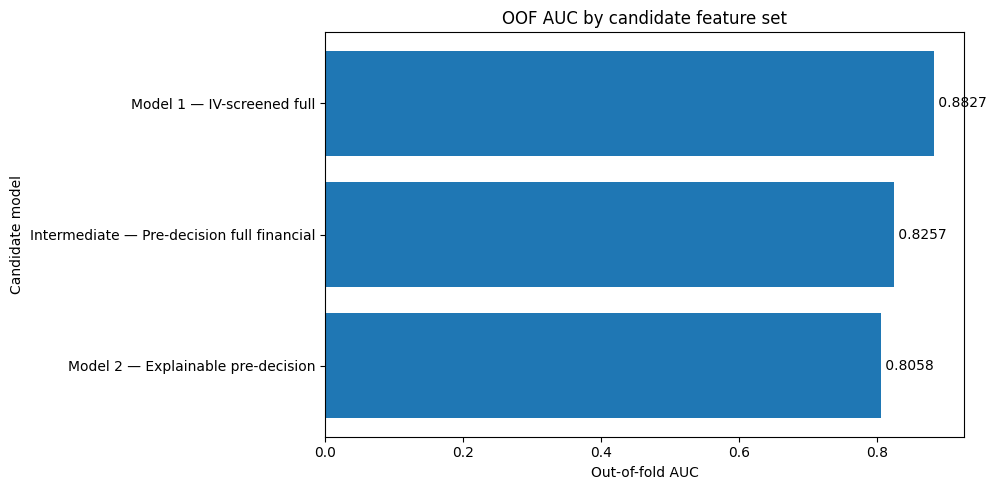

In [11]:
plot_data = (
    candidate_comparison
    .sort_values(
        "OOF AUC",
        ascending=True
    )
)

plt.figure(figsize=(10, 5))

bars = plt.barh(
    plot_data["Model"],
    plot_data["OOF AUC"]
)

for bar, value in zip(
    bars,
    plot_data["OOF AUC"]
):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.4f}",
        va="center"
    )

plt.xlabel("Out-of-fold AUC")
plt.ylabel("Candidate model")
plt.title("OOF AUC by candidate feature set")
plt.tight_layout()
plt.show()

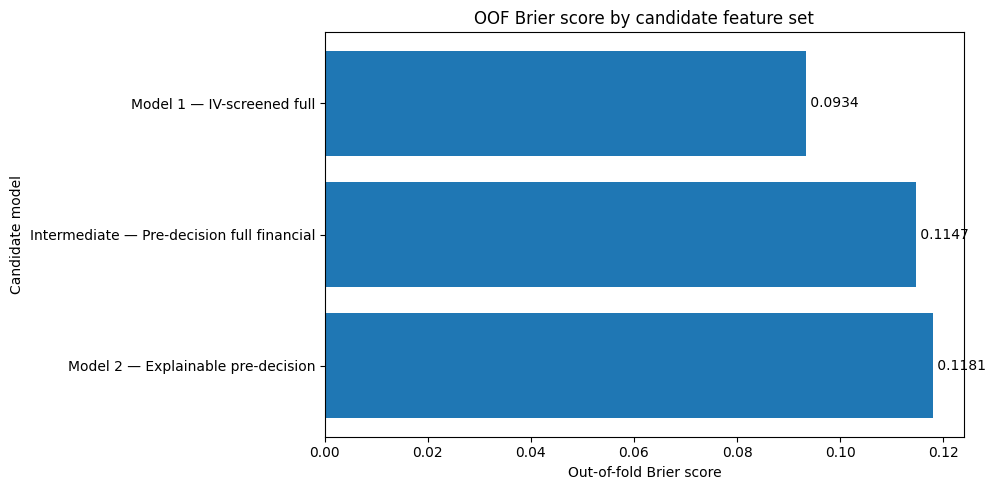

In [12]:
plot_data = (
    candidate_comparison
    .sort_values(
        "OOF Brier",
        ascending=False
    )
)

plt.figure(figsize=(10, 5))

bars = plt.barh(
    plot_data["Model"],
    plot_data["OOF Brier"]
)

for bar, value in zip(
    bars,
    plot_data["OOF Brier"]
):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.4f}",
        va="center"
    )

plt.xlabel("Out-of-fold Brier score")
plt.ylabel("Candidate model")
plt.title("OOF Brier score by candidate feature set")
plt.tight_layout()
plt.show()

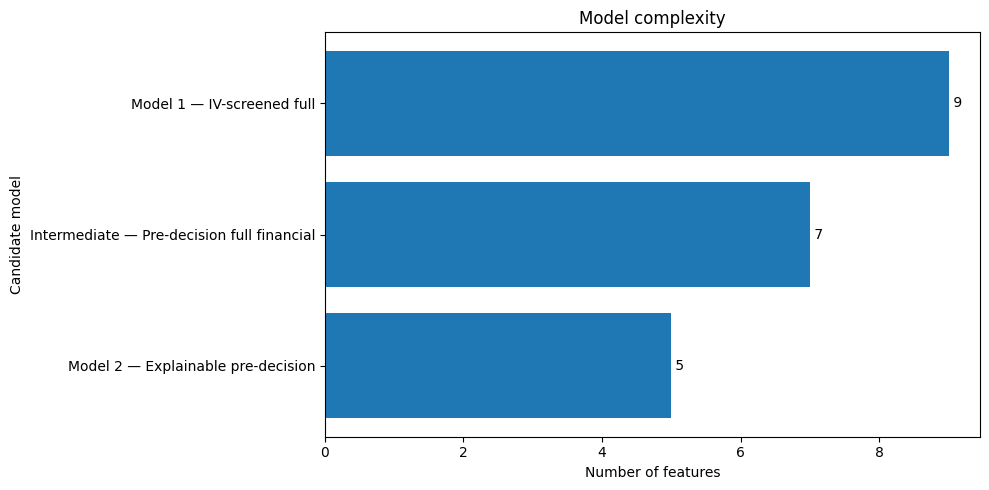

In [13]:
plot_data = (
    candidate_comparison
    .sort_values(
        "Number of features",
        ascending=True
    )
)

plt.figure(figsize=(10, 5))

bars = plt.barh(
    plot_data["Model"],
    plot_data["Number of features"]
)

for bar, value in zip(
    bars,
    plot_data["Number of features"]
):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {int(value)}",
        va="center"
    )

plt.xlabel("Number of features")
plt.ylabel("Candidate model")
plt.title("Model complexity")
plt.tight_layout()
plt.show()

# Bước 9 — Chọn cấu trúc cuối cùng bằng dữ liệu train

Quy tắc lựa chọn được thực hiện như sau:

### Khi `PREDICTION_CONTEXT = "pre_decision"`

Model 1 không đủ điều kiện triển khai vì sử dụng `loan_grade` và `loan_int_rate`.

Chỉ so sánh:

```text
Intermediate — Pre-decision full financial
Model 2 — Explainable pre-decision
```

### Quy tắc 1-SE trong nhóm mô hình hợp lệ

1. Tìm mô hình hợp lệ có Mean CV AUC cao nhất.
2. Tính:

$$
AUC_{\text{threshold}}
=
AUC_{\max}-SE(AUC_{\max}).
$$

3. Giữ các mô hình nằm trong vùng 1-SE.
4. Trong nhóm đó, chọn mô hình có ít biến nhất.
5. Nếu không có mô hình gọn nào gần tốt nhất, chọn mô hình hợp lệ có Mean CV AUC cao nhất.

Quy tắc này ưu tiên tính gọn chỉ khi mức suy giảm hiệu năng nhỏ.

### Manual governance override

Quy tắc tự động chỉ tạo khuyến nghị. Trong dự án thực tế, model governance có thể yêu cầu một cấu trúc cụ thể vì chính sách hoặc khả năng thu thập dữ liệu.

`MANUAL_FINAL_MODEL_KEY` mặc định bằng `None`. Chỉ đặt giá trị khác khi có lý do nghiệp vụ được ghi lại; không override dựa trên kết quả test.


In [14]:
def select_final_model_from_train(
    comparison_table,
    prediction_context
):
    table = comparison_table.copy()

    if prediction_context == "pre_decision":
        eligible_keys = {
            "model_intermediate_predecision_full_financial",
            "model_2_explainable_predecision"
        }
    elif prediction_context == "post_decision":
        eligible_keys = set(
            table["Model key"]
        )
    else:
        raise ValueError(
            "PREDICTION_CONTEXT phải là "
            "'pre_decision' hoặc 'post_decision'."
        )

    table["Business eligible"] = (
        table["Model key"].isin(eligible_keys)
    )

    eligible_table = (
        table.loc[
            table["Business eligible"]
        ]
        .copy()
    )

    best_index = (
        eligible_table["Mean CV AUC"]
        .idxmax()
    )

    best_mean_auc = float(
        eligible_table.loc[
            best_index,
            "Mean CV AUC"
        ]
    )

    best_se_auc = float(
        eligible_table.loc[
            best_index,
            "SE CV AUC"
        ]
    )

    one_se_threshold = (
        best_mean_auc - best_se_auc
    )

    table["Within eligible 1-SE"] = (
        table["Business eligible"]
        & (
            table["Mean CV AUC"]
            >= one_se_threshold
        )
    )

    one_se_candidates = (
        table.loc[
            table["Within eligible 1-SE"]
        ]
        .sort_values(
            [
                "Number of features",
                "Mean CV AUC",
                "OOF Brier"
            ],
            ascending=[
                True,
                False,
                True
            ]
        )
    )

    selected_row = one_se_candidates.iloc[0]

    return {
        "table": table,
        "one_se_threshold": float(
            one_se_threshold
        ),
        "selected_model_key": (
            selected_row["Model key"]
        ),
        "selected_model_label": (
            selected_row["Model"]
        )
    }


# Giữ None để dùng khuyến nghị từ train CV.
# Ví dụ override có quản trị:
# MANUAL_FINAL_MODEL_KEY = "model_2_explainable_predecision"
MANUAL_FINAL_MODEL_KEY = None

selection_result = select_final_model_from_train(
    comparison_table=candidate_comparison,
    prediction_context=PREDICTION_CONTEXT
)

selection_table = selection_result["table"]
ONE_SE_THRESHOLD = selection_result[
    "one_se_threshold"
]
RECOMMENDED_MODEL_KEY = selection_result[
    "selected_model_key"
]

if MANUAL_FINAL_MODEL_KEY is None:
    FINAL_MODEL_KEY = RECOMMENDED_MODEL_KEY
else:
    if MANUAL_FINAL_MODEL_KEY not in CANDIDATE_FEATURE_SETS:
        raise KeyError(
            "MANUAL_FINAL_MODEL_KEY không hợp lệ."
        )

    if PREDICTION_CONTEXT == "pre_decision" and (
        MANUAL_FINAL_MODEL_KEY
        == "model_1_iv_screened_full"
    ):
        raise ValueError(
            "Không thể chọn Model 1 trong "
            "prediction context pre-decision."
        )

    FINAL_MODEL_KEY = MANUAL_FINAL_MODEL_KEY

FINAL_MODEL_LABEL = MODEL_LABELS[
    FINAL_MODEL_KEY
]

FINAL_FEATURES = CANDIDATE_FEATURE_SETS[
    FINAL_MODEL_KEY
]

print(
    "Ngưỡng 1-SE trong nhóm mô hình hợp lệ:",
    f"{ONE_SE_THRESHOLD:.5f}"
)

print("\nCấu trúc được chọn bằng train CV:")
print(FINAL_MODEL_LABEL)

print("\nBiến cuối cùng:")
for feature in FINAL_FEATURES:
    print("-", feature)

display(
    selection_table.style.format({
        "OOF AUC": "{:.5f}",
        "OOF Gini": "{:.5f}",
        "OOF Brier": "{:.5f}",
        "Mean CV AUC": "{:.5f}",
        "SE CV AUC": "{:.5f}",
        "Maximum VIF": "{:.4f}"
    })
)

Ngưỡng 1-SE trong nhóm mô hình hợp lệ: 0.82184

Cấu trúc được chọn bằng train CV:
Intermediate — Pre-decision full financial

Biến cuối cùng:
- person_income
- person_home_ownership
- person_emp_length
- loan_intent
- loan_amnt
- loan_percent_income
- cb_person_default_on_file


,Model key,Model,Number of features,OOF AUC,OOF Gini,OOF Brier,OOF Log loss,OOF KS,Mean CV AUC,SD CV AUC,SE CV AUC,Minimum fold AUC,Maximum fold AUC,Maximum VIF,Any VIF > 5,Calibration intercept,Calibration slope,Business eligible,Within eligible 1-SE
0,model_1_iv_screened_full,Model 1 — IV-screened full,9,0.88270,0.76540,0.09344,0.318366,0.631534,0.88278,0.010988,0.00347,0.867159,0.907063,4.2209,False,-0.002691,0.997104,False,False
1,model_intermediate_predecision_full_financial,Intermediate — Pre-decision full financial,7,0.82573,0.65146,0.11465,0.376422,0.488211,0.82574,0.012334,0.00390,0.807037,0.844087,1.6191,False,-0.002123,0.997931,True,True
2,model_2_explainable_predecision,Model 2 — Explainable pre-decision,5,0.80575,0.61150,0.11811,0.387744,0.452275,0.80579,0.010682,0.00338,0.788725,0.822584,1.0580,False,-0.001439,0.998570,True,False


## Điểm kiểm soát trước khi mở tập test

Tại đây, cấu trúc cuối cùng đã được chọn chỉ bằng:

- Prediction context.
- Cross-validation trên tập train.
- Quy tắc 1-SE.
- Số lượng biến.
- Brier score và VIF như tiêu chí phụ.

Từ cell tiếp theo, tập biến không được thay đổi sau khi xem kết quả test.

# Bước 10 — Kiểm tra độ ổn định hệ số của cấu trúc được chọn

Vì WOE được định nghĩa là:

$$
WOE=\ln\left(\frac{DistGood}{DistBad}\right),
$$

và target bằng 1 là default, hệ số thường được kỳ vọng là âm:

$$
\beta_j<0.
$$

Một biến có tỷ lệ hệ số âm thấp hoặc hệ số đổi dấu giữa các folds cần được rà soát trước khi diễn giải.

In [15]:
final_cv_stability = candidate_results[
    FINAL_MODEL_KEY
]["coefficient_stability"]

display(
    final_cv_stability.style.format({
        "Mean_coefficient": "{:.6f}",
        "SD_coefficient": "{:.6f}",
        "Negative_fold_rate": "{:.1%}"
    })
)

sign_warning = (
    final_cv_stability.loc[
        final_cv_stability[
            "Negative_fold_rate"
        ] < 0.80
    ]
)

if sign_warning.empty:
    print(
        "Không có biến nào có tỷ lệ hệ số âm dưới 80%."
    )
else:
    print(
        "Cảnh báo: các biến cần rà soát dấu hệ số:"
    )
    display(sign_warning)

,Model key,Model,Variable,Mean_coefficient,SD_coefficient,Negative_fold_rate
0,model_intermediate_predecision_full_financial,Intermediate — Pre-decision full financial,cb_person_default_on_file,-1.150367,0.017135,100.0%
1,model_intermediate_predecision_full_financial,Intermediate — Pre-decision full financial,loan_amnt,-0.815658,0.031900,100.0%
2,model_intermediate_predecision_full_financial,Intermediate — Pre-decision full financial,loan_intent,-1.206926,0.027454,100.0%
3,model_intermediate_predecision_full_financial,Intermediate — Pre-decision full financial,loan_percent_income,-0.856526,0.005190,100.0%
4,model_intermediate_predecision_full_financial,Intermediate — Pre-decision full financial,person_emp_length,-0.385371,0.029392,100.0%
5,model_intermediate_predecision_full_financial,Intermediate — Pre-decision full financial,person_home_ownership,-0.886565,0.008244,100.0%
6,model_intermediate_predecision_full_financial,Intermediate — Pre-decision full financial,person_income,-0.761978,0.014331,100.0%


Không có biến nào có tỷ lệ hệ số âm dưới 80%.


## Nhận xét độ ổn định hệ số và quyết định

Tất cả bảy biến trong cấu trúc được chọn có hệ số âm trong **100% số folds**. Kết quả này phù hợp với quy ước:

$$
WOE=\ln\left(\frac{DistGood}{DistBad}\right),
$$

trong khi `loan_status = 1` biểu thị default.

Các độ lệch chuẩn của hệ số giữa các folds cũng tương đối nhỏ so với độ lớn trung bình của hệ số. Không có biến nào có dấu thay đổi thất thường hoặc có tỷ lệ hệ số âm dưới 80%.

Đáng chú ý, `cb_person_default_on_file` có hệ số âm ổn định trong cấu trúc Intermediate. Điều này khắc phục hiện tượng đảo dấu đã xuất hiện khi biến được đưa cùng `loan_grade` và `loan_int_rate` trong cấu trúc đầy đủ.

### Quyết định

- Chấp nhận độ ổn định của tập bảy biến.
- Không loại thêm biến dựa trên dấu hệ số.
- Tiếp tục fit mô hình logistic cuối cùng trên toàn bộ train với đúng bảy biến.

# Bước 11 — Fit mô hình logistic cuối cùng trên toàn bộ train

Sau khi tập biến được khóa, mô hình được fit lại trên toàn bộ tập train:

$$
\operatorname{logit}(PD_i)
=
\beta_0+
\sum_{j=1}^{p}
\beta_jWOE_{ij}.
$$

`statsmodels.GLM` được dùng để lấy:

- Hệ số.
- Standard error.
- Confidence interval.
- P-value.
- Odds ratio.

P-value sau feature selection chỉ mang tính mô tả và không nên là tiêu chí duy nhất để loại thêm biến.

In [16]:
X_train_final = (
    train_woe_dataset[FINAL_FEATURES]
    .astype(float)
)

y_train_final = (
    train_woe_dataset[TARGET]
    .astype(int)
)

X_train_final_constant = sm.add_constant(
    X_train_final,
    has_constant="add"
)

final_model = sm.GLM(
    y_train_final,
    X_train_final_constant,
    family=sm.families.Binomial()
).fit()

print(final_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            loan_status   No. Observations:                25343
Model:                            GLM   Df Residuals:                    25335
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9530.6
Date:                Sat, 01 Aug 2026   Deviance:                       19061.
Time:                        01:27:41   Pearson chi2:                 2.68e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.2518
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [17]:
confidence_interval = (
    final_model.conf_int()
)

coefficient_table = pd.DataFrame({
    "Variable": final_model.params.index,
    "Coefficient": final_model.params.values,
    "Standard error": final_model.bse.values,
    "Z statistic": final_model.tvalues.values,
    "P-value": final_model.pvalues.values,
    "CI lower": confidence_interval[0].values,
    "CI upper": confidence_interval[1].values
})

coefficient_table["Odds ratio"] = np.exp(
    coefficient_table["Coefficient"]
)

coefficient_table[
    "Expected WOE sign"
] = np.where(
    coefficient_table["Variable"] == "const",
    "Not applicable",
    np.where(
        coefficient_table["Coefficient"] < 0,
        "Pass",
        "Review"
    )
)

display(
    coefficient_table.style.format({
        "Coefficient": "{:.6f}",
        "Standard error": "{:.6f}",
        "Z statistic": "{:.4f}",
        "P-value": "{:.6f}",
        "CI lower": "{:.6f}",
        "CI upper": "{:.6f}",
        "Odds ratio": "{:.6f}"
    })
)

,Variable,Coefficient,Standard error,Z statistic,P-value,CI lower,CI upper,Odds ratio,Expected WOE sign
0,const,-1.319853,0.019052,-69.2746,0.000000,-1.357195,-1.282511,0.267175,Not applicable
1,person_income,-0.761879,0.032142,-23.7035,0.000000,-0.824876,-0.698882,0.466788,Pass
2,person_home_ownership,-0.886518,0.031722,-27.9463,0.000000,-0.948692,-0.824343,0.412088,Pass
3,person_emp_length,-0.385450,0.075886,-5.0793,0.000000,-0.534185,-0.236716,0.680144,Pass
4,loan_intent,-1.206978,0.058025,-20.8008,0.000000,-1.320706,-1.093251,0.299100,Pass
5,loan_amnt,-0.815549,0.080429,-10.1400,0.000000,-0.973187,-0.657912,0.442396,Pass
6,loan_percent_income,-0.856457,0.023129,-37.0298,0.000000,-0.901789,-0.811125,0.424664,Pass
7,cb_person_default_on_file,-1.150343,0.042973,-26.7691,0.000000,-1.234568,-1.066118,0.316528,Pass


## Nhận xét mô hình logistic cuối cùng

Tất cả bảy hệ số WOE đều:

- mang dấu âm như kỳ vọng;
- có khoảng tin cậy 95% không chứa 0;
- có p-value rất nhỏ;
- giữ cùng hướng tác động với kết quả cross-validation.

Thứ tự độ lớn hệ số tuyệt đối gồm:

1. `loan_intent`;
2. `cb_person_default_on_file`;
3. `person_home_ownership`;
4. `loan_percent_income`;
5. `loan_amnt`;
6. `person_income`;
7. `person_emp_length`.



Odds ratio trong bảng được hiểu là mức thay đổi của **default odds khi WOE tăng một đơn vị**, không phải khi biến gốc tăng một đơn vị.

### Quyết định

- Giữ toàn bộ bảy biến trong mô hình cuối cùng.
- Sử dụng các hệ số hiện tại để dự báo PD và xây dựng scorecard.

# Bước 12 — Đánh giá trên tập test

Tập test được sử dụng sau khi:

- Prediction context đã được xác định.
- Tập biến cuối cùng đã được khóa.
- Mô hình đã được fit trên toàn bộ train.

Các chỉ tiêu test không được dùng để quay lại thay đổi feature selection hoặc lựa chọn mô hình.

In [18]:
X_test_final = (
    test_woe_dataset[FINAL_FEATURES]
    .astype(float)
)

y_test_final = (
    test_woe_dataset[TARGET]
    .astype(int)
)

X_test_final_constant = sm.add_constant(
    X_test_final,
    has_constant="add"
)

test_probability = np.asarray(
    final_model.predict(
        X_test_final_constant
    ),
    dtype=float
)

test_auc = roc_auc_score(
    y_test_final,
    test_probability
)

test_calibration = calculate_calibration(
    y_true=y_test_final,
    probability=test_probability
)

test_metrics = pd.DataFrame([{
    "Model key": FINAL_MODEL_KEY,
    "Model": FINAL_MODEL_LABEL,
    "Number of features": len(FINAL_FEATURES),
    "Test AUC": float(test_auc),
    "Test Gini": float(2 * test_auc - 1),
    "Test Brier": float(
        brier_score_loss(
            y_test_final,
            test_probability
        )
    ),
    "Test Log loss": float(
        log_loss(
            y_test_final,
            test_probability
        )
    ),
    "Test KS": calculate_ks(
        y_test_final,
        test_probability
    ),
    **test_calibration
}])

display(
    test_metrics.style.format({
        "Test AUC": "{:.5f}",
        "Test Gini": "{:.5f}",
        "Test Brier": "{:.5f}",
        "Test Log loss": "{:.5f}",
        "Test KS": "{:.5f}",
        "Calibration intercept": "{:.4f}",
        "Calibration slope": "{:.4f}"
    })
)

,Model key,Model,Number of features,Test AUC,Test Gini,Test Brier,Test Log loss,Test KS,Calibration intercept,Calibration slope
0,model_intermediate_predecision_full_financial,Intermediate — Pre-decision full financial,7,0.83197,0.66394,0.11289,0.37090,0.50109,0.0357,1.0386


## Nhận xét kết quả trên tập test

Mô hình cuối cùng đạt:

$$
Test\ AUC=0.83197,
$$

$$
Test\ Gini=0.66394,
$$

$$
Test\ KS=0.50109,
$$

$$
Test\ Brier=0.11289,
$$

$$
Test\ Log\ Loss=0.37090.
$$

So với kết quả OOF trên train của cùng cấu trúc:

| Chỉ tiêu | OOF train | Test | Chênh lệch test − OOF |
|---|---:|---:|---:|
| AUC | 0.82573 | 0.83197 | +0.00624 |
| Gini | 0.65146 | 0.66394 | +0.01248 |
| KS | 0.48821 | 0.50109 | +0.01288 |
| Brier | 0.11465 | 0.11289 | −0.00176 |
| Log loss | 0.37642 | 0.37090 | −0.00552 |

Hiệu năng test không suy giảm so với OOF train. Chênh lệch nhỏ và theo hướng tốt hơn, cho thấy mô hình tổng quát hóa ổn định trên tập test hiện tại.

Calibration intercept bằng 0.0357 và calibration slope bằng 1.0386, đều khá gần các giá trị lý tưởng 0 và 1. Intercept dương nhỏ cho thấy mô hình có xu hướng dự báo rủi ro hơi thấp trên tổng thể; slope lớn hơn 1 một chút cho thấy xác suất có thể chưa đủ phân tán. Mức sai lệch này chưa lớn.

### Quyết định

- Chấp nhận mô hình Intermediate làm mô hình cuối cùng cho bộ dữ liệu hiện tại.
- Không thay đổi biến, bin hoặc hệ số sau khi xem kết quả test.
- Không hiệu chỉnh calibration trực tiếp bằng chính tập test.
- Giữ test metrics làm ước lượng hiệu năng ngoài mẫu cuối cùng của notebook.

## ROC curve trên tập test

ROC curve mô tả sự đánh đổi giữa:

- True Positive Rate.
- False Positive Rate.

Đường chéo biểu thị mô hình không có khả năng phân biệt.

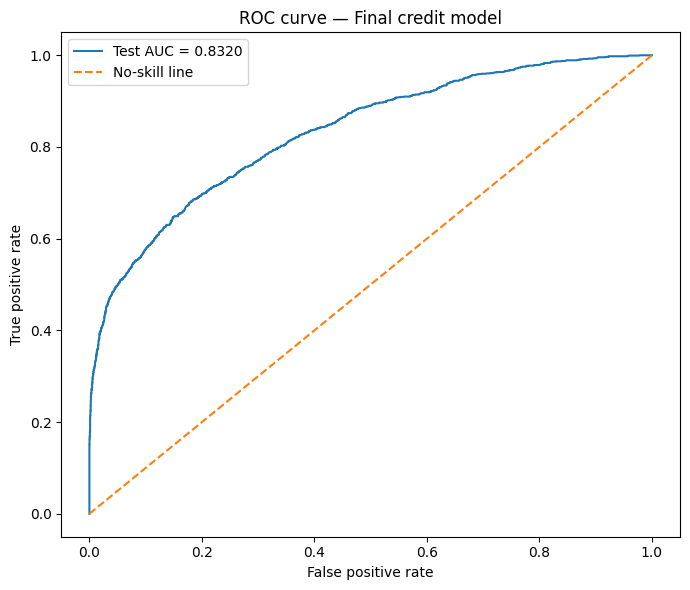

In [19]:
test_fpr, test_tpr, _ = roc_curve(
    y_test_final,
    test_probability
)

plt.figure(figsize=(7, 6))

plt.plot(
    test_fpr,
    test_tpr,
    label=f"Test AUC = {test_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="No-skill line"
)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve — Final credit model")
plt.legend()
plt.tight_layout()
plt.show()

## Calibration plot trên tập test

Calibration plot so sánh:

- Xác suất default trung bình do mô hình dự báo.
- Tỷ lệ default thực tế.

Các điểm càng gần đường 45 độ thì xác suất dự báo càng phù hợp với tỷ lệ quan sát.

In [20]:
def create_calibration_table(
    y_true,
    probability,
    number_of_groups=10
):
    table = pd.DataFrame({
        "Actual": np.asarray(y_true, dtype=int),
        "Predicted PD": np.asarray(
            probability,
            dtype=float
        )
    })

    table["PD band"] = pd.qcut(
        table["Predicted PD"],
        q=number_of_groups,
        duplicates="drop"
    )

    return (
        table
        .groupby(
            "PD band",
            observed=True
        )
        .agg(
            Number_of_observations=(
                "Actual",
                "size"
            ),
            Mean_predicted_PD=(
                "Predicted PD",
                "mean"
            ),
            Actual_bad_rate=(
                "Actual",
                "mean"
            )
        )
        .reset_index()
    )


test_calibration_table = create_calibration_table(
    y_true=y_test_final,
    probability=test_probability,
    number_of_groups=10
)

display(
    test_calibration_table.style.format({
        "Mean_predicted_PD": "{:.2%}",
        "Actual_bad_rate": "{:.2%}"
    })
)

,PD band,Number_of_observations,Mean_predicted_PD,Actual_bad_rate
0,"(0.00419, 0.0276]",634,1.94%,1.89%
1,"(0.0276, 0.0437]",634,3.53%,4.89%
2,"(0.0437, 0.0639]",636,5.39%,7.39%
3,"(0.0639, 0.0913]",631,7.64%,8.08%
4,"(0.0913, 0.122]",634,10.61%,11.99%
5,"(0.122, 0.168]",633,14.58%,15.48%
6,"(0.168, 0.242]",633,20.36%,17.22%
7,"(0.242, 0.365]",635,29.50%,25.04%
8,"(0.365, 0.593]",632,45.89%,38.29%
9,"(0.593, 0.97]",634,76.36%,85.17%


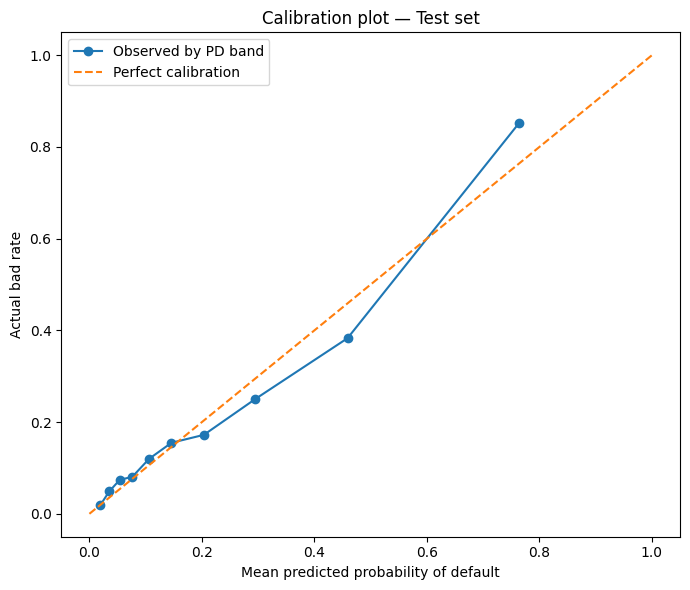

In [21]:
plt.figure(figsize=(7, 6))

plt.plot(
    test_calibration_table[
        "Mean_predicted_PD"
    ],
    test_calibration_table[
        "Actual_bad_rate"
    ],
    marker="o",
    label="Observed by PD band"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability of default")
plt.ylabel("Actual bad rate")
plt.title("Calibration plot — Test set")
plt.legend()
plt.tight_layout()
plt.show()

## Nhận xét calibration theo nhóm xác suất

Tỷ lệ default thực tế nhìn chung tăng theo xác suất dự báo, cho thấy mô hình sắp xếp rủi ro đúng hướng.

Các nhóm xác suất thấp có mức dự báo và tỷ lệ default thực tế khá gần nhau. Tuy nhiên, một số chênh lệch xuất hiện ở hai đầu phân phối:

- Ở nhóm có PD dự báo trung bình 45,89%, bad rate thực tế là 38,29%: mô hình dự báo cao hơn thực tế khoảng 7,60 điểm phần trăm.
- Ở nhóm rủi ro cao nhất, PD dự báo trung bình là 76,36%, trong khi bad rate thực tế là 85,17%: mô hình dự báo thấp hơn thực tế khoảng 8,81 điểm phần trăm.

Như vậy, calibration tổng thể tốt nhưng chưa hoàn hảo ở các vùng cực trị.

### Quyết định

- Không recalibrate bằng tập test vì điều đó làm mất tính độc lập của test.
- Chấp nhận calibration hiện tại cho mục tiêu nghiên cứu và xây dựng scorecard.
- Khi triển khai thực tế, cần kiểm tra lại calibration bằng dữ liệu out-of-time hoặc một calibration set riêng, đặc biệt ở nhóm rủi ro cao nhất.

# Bước 13 — Chọn quy ước Credit Score

Scorecard sử dụng ba tham số:

- **Base Score:** điểm tại một mức odds cơ sở.
- **Base Odds:** Good:Bad odds tại Base Score.
- **PDO:** số điểm tăng khi Good:Bad odds tăng gấp đôi.

Ví dụ:

```text
Base Score = 600
Base Odds = 50:1
PDO = 20
```

Nghĩa là:

- Điểm 600 tương ứng Good:Bad odds bằng 50:1.
- Khi Good:Bad odds tăng từ 50:1 lên 100:1, score tăng 20 điểm.

Điểm cao hơn phải tương ứng với PD thấp hơn.

In [22]:
# ============================================================
# SCORE SCALING
# ============================================================

BASE_SCORE = 600
BASE_ODDS_GOOD_TO_BAD = 50
PDO = 20

FACTOR = PDO / np.log(2)

OFFSET = (
    BASE_SCORE
    - FACTOR
    * np.log(BASE_ODDS_GOOD_TO_BAD)
)

score_scaling_table = pd.DataFrame([{
    "Base score": BASE_SCORE,
    "Base Good:Bad odds": (
        BASE_ODDS_GOOD_TO_BAD
    ),
    "PDO": PDO,
    "Factor": FACTOR,
    "Offset": OFFSET
}])

display(
    score_scaling_table.style.format({
        "Factor": "{:.6f}",
        "Offset": "{:.6f}"
    })
)

,Base score,Base Good:Bad odds,PDO,Factor,Offset
0,600,50,20,28.853901,487.122876


# Bước 14 — Chuyển PD và odds thành score

Mô hình logistic trả về:

$$
\operatorname{logit}(PD)
=
\ln\left(\frac{PD}{1-PD}\right).
$$

Good:Bad odds là:

$$
Odds_{Good:Bad}
=
\frac{1-PD}{PD}.
$$

Công thức điểm:

$$
Score
=
Offset
+
Factor\ln(Odds_{Good:Bad}),
$$

tương đương:

$$
Score
=
Offset
-
Factor\times\operatorname{logit}(PD).
$$

In [23]:
def probability_to_score(
    probability,
    offset,
    factor
):
    probability = np.clip(
        np.asarray(
            probability,
            dtype=float
        ),
        1e-8,
        1 - 1e-8
    )

    logit_pd = np.log(
        probability
        / (1 - probability)
    )

    return (
        offset
        - factor * logit_pd
    )


def score_to_probability(
    score,
    offset,
    factor
):
    score = np.asarray(
        score,
        dtype=float
    )

    logit_pd = (
        offset - score
    ) / factor

    return (
        1
        / (
            1 + np.exp(-logit_pd)
        )
    )


base_pd = (
    1
    / (
        1 + BASE_ODDS_GOOD_TO_BAD
    )
)

base_score_check = probability_to_score(
    probability=base_pd,
    offset=OFFSET,
    factor=FACTOR
)

double_odds_pd = (
    1
    / (
        1
        + 2 * BASE_ODDS_GOOD_TO_BAD
    )
)

double_odds_score = probability_to_score(
    probability=double_odds_pd,
    offset=OFFSET,
    factor=FACTOR
)

print(
    "Score tại base odds:",
    float(base_score_check)
)

print(
    "Score khi Good:Bad odds tăng gấp đôi:",
    float(double_odds_score)
)

print(
    "Chênh lệch điểm:",
    float(
        double_odds_score
        - base_score_check
    )
)

Score tại base odds: 600.0
Score khi Good:Bad odds tăng gấp đôi: 620.0
Chênh lệch điểm: 20.0


# Bước 15 — Tính score trực tiếp từ mô hình logistic

Với:

$$
\operatorname{logit}(PD)
=
\beta_0+
\sum_{j=1}^{p}\beta_jWOE_j,
$$

ta có:

$$
Score
=
Offset
-
Factor
\left(
\beta_0+
\sum_{j=1}^{p}\beta_jWOE_j
\right).
$$

Điểm cơ sở:

$$
BasePoints
=
Offset-Factor\beta_0.
$$

Điểm đóng góp của biến $j$:

$$
Points_j
=
-Factor\beta_jWOE_j.
$$

Không làm tròn điểm từng biến trước khi cộng tổng.

In [24]:
intercept = float(
    final_model.params["const"]
)

BASE_POINTS = (
    OFFSET
    - FACTOR * intercept
)

test_linear_predictor = np.asarray(
    X_test_final_constant
    @ final_model.params,
    dtype=float
)

test_score_from_logit = (
    OFFSET
    - FACTOR
    * test_linear_predictor
)

test_score_from_probability = (
    probability_to_score(
        probability=test_probability,
        offset=OFFSET,
        factor=FACTOR
    )
)

maximum_score_difference = float(
    np.max(
        np.abs(
            test_score_from_logit
            - test_score_from_probability
        )
    )
)

print("Base points:", BASE_POINTS)

print(
    "Maximum difference giữa hai cách tính score:",
    maximum_score_difference
)

if maximum_score_difference > 1e-8:
    warnings.warn(
        "Hai cách tính score chưa khớp như kỳ vọng."
    )

Base points: 525.2057895552532
Maximum difference giữa hai cách tính score: 1.1368683772161603e-13


## Nhận xét và quyết định về quy ước điểm

Quy ước scorecard được thiết lập:

```text
Base Score = 600
Base Good:Bad Odds = 50:1
PDO = 20
```

Kiểm tra cho thấy:

- Good:Bad odds bằng 50:1 tương ứng đúng 600 điểm.
- Khi Good:Bad odds tăng gấp đôi, điểm tăng đúng 20 điểm.

Như vậy, công thức `Factor` và `Offset` được triển khai nhất quán với quy ước Good:Bad odds.

### Quyết định

- Chấp nhận quy ước 600 điểm tại odds 50:1 và PDO bằng 20 cho scorecard hiện tại.
- Xem đây là quy ước scaling, không phải tiêu chí đánh giá chất lượng dự báo.
- Khi có yêu cầu nghiệp vụ chính thức, Base Score, Base Odds và PDO có thể được đổi mà không cần fit lại mô hình logistic.

# Bước 16 — Tạo bảng Scorecard theo từng bin

Với mỗi bin của biến $j$:

$$
BinPoints_{j,b}
=
-Factor
\times
\beta_j
\times
WOE_{j,b}.
$$

Bảng scorecard lưu cả:

- Bin.
- Count và event rate trên train.
- WOE.
- Hệ số logistic.
- Điểm dạng số thực.
- Điểm làm tròn để trình bày.

Tổng score chính thức vẫn được tính bằng điểm dạng số thực hoặc trực tiếp từ linear predictor.

In [25]:
def build_scorecard_table(
    cleaned_tables,
    model_params,
    features,
    factor
):
    rows = []

    for feature in features:
        if feature not in cleaned_tables:
            raise KeyError(
                f"Không tìm thấy binning table của '{feature}'."
            )

        feature_table = (
            cleaned_tables[feature]
            .copy()
        )

        # Loại dòng tổng nhưng giữ Missing/Special bins,
        # kể cả khi Count trên train bằng 0.
        index_labels = (
            feature_table.index
            .astype(str)
            .str.strip()
        )

        feature_table = feature_table.loc[
            ~index_labels.isin(
                ["Totals", "Total"]
            )
        ].copy()

        if "Bin" in feature_table.columns:
            bin_labels = (
                feature_table["Bin"]
                .astype(str)
                .str.strip()
            )

            feature_table = feature_table.loc[
                ~bin_labels.isin(
                    ["Totals", "Total"]
                )
            ].copy()

        required_columns = {
            "Bin",
            "WoE"
        }

        missing_columns = (
            required_columns
            - set(feature_table.columns)
        )

        if missing_columns:
            raise KeyError(
                f"Binning table của {feature} thiếu: "
                f"{sorted(missing_columns)}"
            )

        coefficient = float(
            model_params[feature]
        )

        for _, row in feature_table.iterrows():
            woe_value = float(
                row["WoE"]
            )

            raw_points = (
                -factor
                * coefficient
                * woe_value
            )

            rows.append({
                "Variable": feature,
                "Bin": row["Bin"],
                "Count": row.get(
                    "Count",
                    np.nan
                ),
                "Event rate": row.get(
                    "Event rate",
                    np.nan
                ),
                "WOE": woe_value,
                "Coefficient": coefficient,
                "Raw points": raw_points,
                "Rounded points": int(
                    np.rint(raw_points)
                )
            })

    return pd.DataFrame(rows)


scorecard_table = build_scorecard_table(
    cleaned_tables=binning_tables,
    model_params=final_model.params,
    features=FINAL_FEATURES,
    factor=FACTOR
)

base_points_table = pd.DataFrame([{
    "Component": "Base points",
    "Value": BASE_POINTS,
    "Rounded value": int(
        np.rint(BASE_POINTS)
    )
}])

display(
    base_points_table.style.format({
        "Value": "{:.6f}"
    })
)

display(
    scorecard_table.style.format({
        "Event rate": "{:.2%}",
        "WOE": "{:.6f}",
        "Coefficient": "{:.6f}",
        "Raw points": "{:.4f}"
    })
)

,Component,Value,Rounded value
0,Base points,525.205790,525


,Variable,Bin,Count,Event rate,WOE,Coefficient,Raw points,Rounded points
0,person_income,"(-inf, 24228.00)",1531,53.82%,-1.445556,-0.761879,-31.7779,-32
1,person_income,"[24228.00, 34999.50)",3135,39.94%,-0.884292,-0.761879,-19.4396,-19
2,person_income,"[34999.50, 39937.50)",1774,26.38%,-0.266160,-0.761879,-5.8511,-6
3,person_income,"[39937.50, 59748.50)",7152,21.13%,0.024873,-0.761879,0.5468,1
4,person_income,"[59748.50, 79993.50)",5363,15.22%,0.425392,-0.761879,9.3515,9
5,person_income,"[79993.50, inf)",6388,9.22%,0.994598,-0.761879,21.8644,22
6,person_income,Special,0,0.00%,0.000000,-0.761879,0.0000,0
7,person_income,Missing,0,0.00%,0.000000,-0.761879,0.0000,0
8,person_home_ownership,['OWN'],1929,6.58%,1.360049,-0.886518,34.7894,35
9,person_home_ownership,['MORTGAGE'],10472,12.59%,0.645659,-0.886518,16.5156,17


## Nhận xét bảng Scorecard theo bin

Bảng scorecard có **49 dòng**, bao gồm các bin thông thường, `Special` và `Missing` của bảy biến.

Hướng điểm nhìn chung phù hợp với bad rate:

- Thu nhập cao hơn nhận nhiều điểm hơn.
- Sở hữu nhà nhận nhiều điểm hơn thuê nhà hoặc nhóm khác.
- Thời gian làm việc dài hơn nhận nhiều điểm hơn.
- `loan_percent_income` cao làm giảm điểm rất mạnh.
- Khách hàng từng có default nhận ít điểm hơn rõ rệt.
- Khoản vay lớn nhìn chung nhận ít điểm hơn các khoản vay vừa và nhỏ.

`loan_percent_income` tạo khoảng điểm rộng nhất, từ khoảng +21 đến −57 điểm. Điều này phù hợp với việc đây là biến có IV cao nhất trong nhóm pre-decision.

Các bin `Special` và `Missing` có số quan sát bằng 0 trong train, nên hiện được gán WOE và điểm bằng 0. Đây là cách xử lý kỹ thuật trong bộ dữ liệu hiện tại, nhưng chưa phải chính sách fallback đầy đủ cho dữ liệu sản xuất.

### Quyết định

- Chấp nhận bảng điểm được tạo từ hệ số và WOE hiện tại.
- Giữ điểm dạng số thực làm nguồn chuẩn; cột điểm làm tròn chỉ dùng cho trình bày hoặc triển khai sau khi kiểm tra sai lệch tổng điểm.
- Trước khi triển khai thực tế, phải định nghĩa chính sách cho missing, special và giá trị chưa từng xuất hiện; không mặc định sử dụng 0 điểm mà không có phê duyệt nghiệp vụ.

# Bước 17 — Tạo scored dataset và kiểm tra score

Mỗi quan sát trong test được bổ sung:

- Actual target.
- Predicted PD.
- Good:Bad odds.
- Credit Score.

Kiểm tra bắt buộc:

$$
Correlation(Score,PD)<0.
$$

Điểm càng cao thì xác suất default phải càng thấp.

In [26]:
test_good_to_bad_odds = (
    1 - test_probability
) / test_probability

scored_test_dataset = pd.DataFrame(
    index=test_woe_dataset.index
)

scored_test_dataset["Actual"] = (
    y_test_final
)

scored_test_dataset[
    "Predicted PD"
] = test_probability

scored_test_dataset[
    "Good:Bad odds"
] = test_good_to_bad_odds

scored_test_dataset[
    "Credit Score"
] = test_score_from_logit

scored_test_dataset[
    "Rounded Credit Score"
] = np.rint(
    scored_test_dataset[
        "Credit Score"
    ]
).astype(int)

score_pd_correlation = float(
    scored_test_dataset[
        [
            "Credit Score",
            "Predicted PD"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    "Correlation giữa Credit Score và PD:",
    score_pd_correlation
)

if score_pd_correlation >= 0:
    raise RuntimeError(
        "Score phải tương quan âm với PD."
    )

display(
    scored_test_dataset.head()
)

Correlation giữa Credit Score và PD: -0.9526106091604282


,Actual,Predicted PD,Good:Bad odds,Credit Score,Rounded Credit Score
original_index,,,,,
16932,0,0.063321,14.792660,564.859069,565
25616,0,0.019523,50.220523,600.126979,600
15675,0,0.022863,42.738282,595.472016,595
15741,0,0.073487,12.607809,560.247790,560
13721,0,0.058835,15.996619,567.116779,567


## Nhận xét quan hệ giữa Credit Score và PD

Hệ số tương quan giữa Credit Score và predicted PD bằng:

$$
-0.9526.
$$

Mối liên hệ âm rất mạnh xác nhận hướng của scorecard:

```text
Credit Score tăng
→ Predicted PD giảm
→ Good:Bad odds tăng
```

### Quyết định

- Xác nhận chiều điểm đúng: điểm cao đại diện cho rủi ro thấp.


# Bước 18 — Kiểm tra score band

Dữ liệu test được chia thành mười nhóm theo Credit Score.

Kỳ vọng:

```text
Score tăng
→ Predicted PD giảm
→ Actual bad rate giảm
```

Score band dùng để kiểm tra khả năng xếp hạng và tính dễ diễn giải của scorecard, không dùng để quay lại điều chỉnh mô hình.

In [27]:
scored_test_dataset[
    "Score band"
] = pd.qcut(
    scored_test_dataset[
        "Credit Score"
    ],
    q=10,
    duplicates="drop"
)

score_band_summary = (
    scored_test_dataset
    .groupby(
        "Score band",
        observed=True
    )
    .agg(
        Number_of_observations=(
            "Actual",
            "size"
        ),
        Minimum_score=(
            "Credit Score",
            "min"
        ),
        Maximum_score=(
            "Credit Score",
            "max"
        ),
        Average_score=(
            "Credit Score",
            "mean"
        ),
        Average_predicted_PD=(
            "Predicted PD",
            "mean"
        ),
        Actual_bad_rate=(
            "Actual",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "Average_score",
        ascending=False
    )
    .reset_index(drop=True)
)

score_band_summary[
    "Score rank"
] = np.arange(
    1,
    len(score_band_summary) + 1
)

display(
    score_band_summary.style.format({
        "Minimum_score": "{:.2f}",
        "Maximum_score": "{:.2f}",
        "Average_score": "{:.2f}",
        "Average_predicted_PD": "{:.2%}",
        "Actual_bad_rate": "{:.2%}"
    })
)

,Score band,Number_of_observations,Minimum_score,Maximum_score,Average_score,Average_predicted_PD,Actual_bad_rate,Score rank
0,"(589.907, 638.772]",634,589.91,638.77,601.48,1.94%,1.89%,1
1,"(576.177, 589.907]",630,576.19,589.90,582.82,3.53%,4.92%,2
2,"(564.581, 576.177]",633,564.61,576.18,570.09,5.37%,6.64%,3
3,"(553.441, 564.581]",637,553.47,564.58,559.24,7.63%,8.79%,4
4,"(543.998, 553.441]",633,544.05,553.44,548.74,10.61%,12.01%,5
5,"(533.19, 543.998]",629,533.21,544.00,538.32,14.55%,15.42%,6
6,"(520.084, 533.19]",639,520.10,533.19,526.69,20.32%,17.21%,7
7,"(503.118, 520.084]",632,503.13,520.07,512.47,29.47%,25.00%,8
8,"(476.319, 503.118]",635,476.34,503.12,492.00,45.85%,38.27%,9
9,"(386.53700000000003, 476.319]",634,386.54,476.29,449.95,76.36%,85.17%,10


## Nhận xét score bands và quyết định

Credit Score trên tập test nằm trong khoảng xấp xỉ:

$$
386.54\ \text{đến}\ 638.77.
$$

Bad rate thực tế thay đổi đơn điệu theo score band:

| Thứ hạng điểm | Điểm trung bình | Bad rate thực tế |
|---:|---:|---:|
| 1 — điểm cao nhất | 601.48 | 1.89% |
| 2 | 582.82 | 4.92% |
| 3 | 570.09 | 6.64% |
| 4 | 559.24 | 8.79% |
| 5 | 548.74 | 12.01% |
| 6 | 538.32 | 15.42% |
| 7 | 526.69 | 17.21% |
| 8 | 512.47 | 25.00% |
| 9 | 492.00 | 38.27% |
| 10 — điểm thấp nhất | 449.95 | 85.17% |

Khi điểm giảm, predicted PD và bad rate thực tế đều tăng. Không có hiện tượng đảo thứ tự giữa các score bands. Điều này cho thấy scorecard phân tầng rủi ro tốt và dễ diễn giải.

### Quyết định

- Chấp nhận khả năng phân hạng của scorecard.
- Chưa chọn approval cut-off trong notebook này.
- Cut-off phải được xác định ở bước policy bằng chi phí sai lầm, expected loss, rủi ro và năng lực phê duyệt, không chỉ bằng AUC hoặc score distribution.

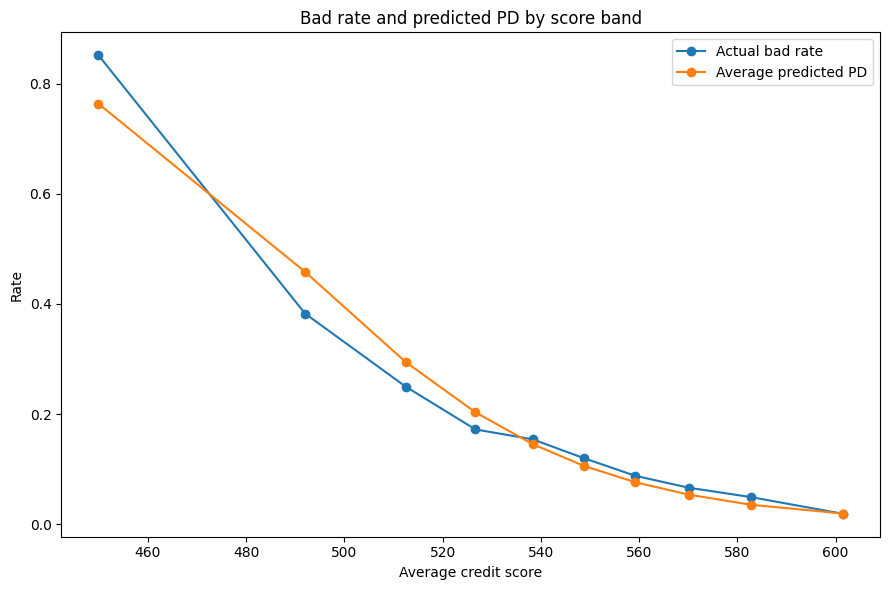

In [28]:
plot_data = (
    score_band_summary
    .sort_values(
        "Average_score",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

plt.plot(
    plot_data["Average_score"],
    plot_data["Actual_bad_rate"],
    marker="o",
    label="Actual bad rate"
)

plt.plot(
    plot_data["Average_score"],
    plot_data["Average_predicted_PD"],
    marker="o",
    label="Average predicted PD"
)

plt.xlabel("Average credit score")
plt.ylabel("Rate")
plt.title("Bad rate and predicted PD by score band")
plt.legend()
plt.tight_layout()
plt.show()

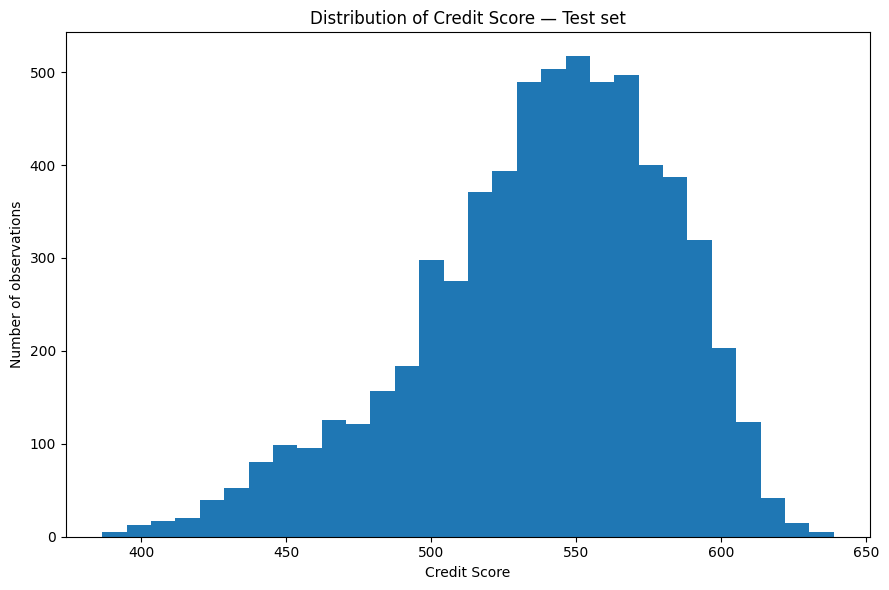

In [29]:
plt.figure(figsize=(9, 6))

plt.hist(
    scored_test_dataset[
        "Credit Score"
    ],
    bins=30
)

plt.xlabel("Credit Score")
plt.ylabel("Number of observations")
plt.title("Distribution of Credit Score — Test set")
plt.tight_layout()
plt.show()

# Bước 19 — Nhật ký quyết định mô hình

Bảng dưới đây tổng hợp các quyết định đã được khóa trong notebook. Việc lưu decision log giúp phân biệt rõ:

- kết quả thống kê;
- ràng buộc nghiệp vụ;
- quyết định mô hình;
- những nội dung chưa được quyết định.

Decision log cũng được xuất cùng các file model để phục vụ kiểm tra và tái lập.

In [30]:
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    log_loss,
    roc_curve,
)

# ============================================================
# TẠO CÁC TEST METRICS DẠNG SCALAR
# ============================================================

test_auc = roc_auc_score(
    y_test_final,
    test_probability,
)

test_gini = 2 * test_auc - 1

test_brier = brier_score_loss(
    y_test_final,
    test_probability,
)

test_log_loss = log_loss(
    y_test_final,
    test_probability,
)

# KS = max(TPR - FPR)
test_fpr, test_tpr, test_thresholds = roc_curve(
    y_test_final,
    test_probability,
)

test_ks = float(
    np.max(test_tpr - test_fpr)
)

print("Test AUC:", f"{test_auc:.5f}")
print("Test Gini:", f"{test_gini:.5f}")
print("Test KS:", f"{test_ks:.5f}")
print("Test Brier:", f"{test_brier:.5f}")
print("Test Log Loss:", f"{test_log_loss:.5f}")

model_decision_log = pd.DataFrame([
    {
        "Decision area": "Prediction context",
        "Decision": "Pre-decision",
        "Evidence": (
            "loan_grade and loan_int_rate are not assumed "
            "available at scoring time."
        )
    },
    {
        "Decision area": "Final model structure",
        "Decision": FINAL_MODEL_LABEL,
        "Evidence": (
            "Business eligible and within the 1-SE region; "
            "better OOF AUC/Gini/Brier than the 5-feature model."
        )
    },
    {
        "Decision area": "Final features",
        "Decision": " | ".join(FINAL_FEATURES),
        "Evidence": (
            "Locked before test evaluation."
        )
    },
    {
        "Decision area": "Test evaluation",
        "Decision": "Accept final model",
        "Evidence": (
            f"Test AUC={test_auc:.5f}, "
            f"Gini={test_gini:.5f}, "
            f"KS={test_ks:.5f}; "
            "performance is consistent with train OOF."
        )
    },
    {
        "Decision area": "Calibration",
        "Decision": "No recalibration on test",
        "Evidence": (
            f"Intercept={test_calibration['Calibration intercept']:.4f}, "
            f"slope={test_calibration['Calibration slope']:.4f}; "
            "test remains evaluation-only."
        )
    },
    {
        "Decision area": "Score scaling",
        "Decision": (
            f"Base score={BASE_SCORE}, "
            f"Good:Bad odds={BASE_ODDS_GOOD_TO_BAD}:1, "
            f"PDO={PDO}"
        ),
        "Evidence": (
            "Scaling identity validated; changing scaling "
            "does not require model refitting."
        )
    },
    {
        "Decision area": "Score direction",
        "Decision": "Higher score means lower default risk",
        "Evidence": (
            f"Correlation(score, PD)={score_pd_correlation:.4f}."
        )
    },
    {
        "Decision area": "Approval cut-off",
        "Decision": "Not selected in this notebook",
        "Evidence": (
            "Requires business costs, expected loss and risk appetite."
        )
    }
])

display(model_decision_log)

Test AUC: 0.83197
Test Gini: 0.66394
Test KS: 0.50109
Test Brier: 0.11289
Test Log Loss: 0.37090


,Decision area,Decision,Evidence
0,Prediction context,Pre-decision,loan_grade and loan_int_rate are not assumed available at scoring time.
1,Final model structure,Intermediate — Pre-decision full financial,Business eligible and within the 1-SE region; better OOF AUC/Gini/Brier than the 5-feature model.
2,Final features,person_income | person_home_ownership | person_emp_length | loan_intent | loan_amnt | loan_percent_income | cb_perso...,Locked before test evaluation.
3,Test evaluation,Accept final model,"Test AUC=0.83197, Gini=0.66394, KS=0.50109; performance is consistent with train OOF."
4,Calibration,No recalibration on test,"Intercept=0.0357, slope=1.0386; test remains evaluation-only."
5,Score scaling,"Base score=600, Good:Bad odds=50:1, PDO=20",Scaling identity validated; changing scaling does not require model refitting.
6,Score direction,Higher score means lower default risk,"Correlation(score, PD)=-0.9526."
7,Approval cut-off,Not selected in this notebook,"Requires business costs, expected loss and risk appetite."


In [31]:
model_scorecard_metadata = {
    "target": TARGET,
    "prediction_context": PREDICTION_CONTEXT,
    "final_model_key": FINAL_MODEL_KEY,
    "final_model_label": FINAL_MODEL_LABEL,
    "final_features": FINAL_FEATURES,
    "selection_method": (
        "Business eligibility followed by "
        "one-standard-error rule on train CV."
    ),
    "test_usage": (
        "Test evaluated once after feature set "
        "and model structure were locked."
    ),
    "score_scaling": {
        "base_score": BASE_SCORE,
        "base_odds_good_to_bad": (
            BASE_ODDS_GOOD_TO_BAD
        ),
        "pdo": PDO,
        "factor": float(FACTOR),
        "offset": float(OFFSET),
        "base_points": float(BASE_POINTS),
        "score_direction": (
            "Higher score means lower probability "
            "of default."
        )
    },
    "test_metrics": (
        test_metrics
        .iloc[0]
        .to_dict()
    ),
    "maximum_score_identity_difference": (
        maximum_score_difference
    ),
    "score_pd_correlation": (
        score_pd_correlation
    )
}

# Chuyển numpy scalar về kiểu JSON-compatible.
for key, value in list(
    model_scorecard_metadata[
        "test_metrics"
    ].items()
):
    if isinstance(
        value,
        (
            np.integer,
            np.floating,
            np.bool_
        )
    ):
        model_scorecard_metadata[
            "test_metrics"
        ][key] = value.item()

with open(
    MODEL_OUTPUT_DIR
    / "model_scorecard_metadata.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_scorecard_metadata,
        file,
        ensure_ascii=False,
        indent=4
    )

print("Đã lưu Model Development artifacts tại:")
print(MODEL_OUTPUT_DIR)

Đã lưu Model Development artifacts tại:
/content/drive/MyDrive/AIO 2026/Conquer/Data/train_test_feature_selection/model_development_scorecard


# Bước 20 — Xuất model và scorecard files.

Các files cần lưu:

```text
candidate_model_comparison.csv
candidate_coefficient_stability.csv
final_model_coefficients.csv
test_metrics.csv
test_calibration_table.csv
score_scaling.csv
scorecard_table.csv
score_band_summary.csv
scored_test_dataset.csv
final_model_statsmodels.pickle
model_scorecard_metadata.json
model_decision_log.csv
```

`model_scorecard_metadata.json` ghi lại:

- Tập biến cuối cùng.
- Prediction context.
- Score scaling.
- Test metrics.
- Quy ước Good:Bad odds.
- Nhật ký các quyết định mô hình.

In [32]:
all_coefficient_stability = pd.concat(
    [
        result["coefficient_stability"]
        for result in candidate_results.values()
    ],
    ignore_index=True
)

candidate_comparison.to_csv(
    MODEL_OUTPUT_DIR
    / "candidate_model_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

all_coefficient_stability.to_csv(
    MODEL_OUTPUT_DIR
    / "candidate_coefficient_stability.csv",
    index=False,
    encoding="utf-8-sig"
)

coefficient_table.to_csv(
    MODEL_OUTPUT_DIR
    / "final_model_coefficients.csv",
    index=False,
    encoding="utf-8-sig"
)

test_metrics.to_csv(
    MODEL_OUTPUT_DIR
    / "test_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

test_calibration_table.to_csv(
    MODEL_OUTPUT_DIR
    / "test_calibration_table.csv",
    index=False,
    encoding="utf-8-sig"
)

score_scaling_table.to_csv(
    MODEL_OUTPUT_DIR
    / "score_scaling.csv",
    index=False,
    encoding="utf-8-sig"
)

scorecard_table.to_csv(
    MODEL_OUTPUT_DIR
    / "scorecard_table.csv",
    index=False,
    encoding="utf-8-sig"
)

score_band_summary.to_csv(
    MODEL_OUTPUT_DIR
    / "score_band_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

scored_test_dataset.to_csv(
    MODEL_OUTPUT_DIR
    / "scored_test_dataset.csv",
    index=True,
    index_label="original_index",
    encoding="utf-8-sig"
)


model_decision_log.to_csv(
    MODEL_OUTPUT_DIR
    / "model_decision_log.csv",
    index=False,
    encoding="utf-8-sig"
)

final_model.save(
    MODEL_OUTPUT_DIR
    / "final_model_statsmodels.pickle"
)

In [33]:
model_scorecard_metadata = {
    "target": TARGET,
    "prediction_context": PREDICTION_CONTEXT,
    "final_model_key": FINAL_MODEL_KEY,
    "final_model_label": FINAL_MODEL_LABEL,
    "final_features": FINAL_FEATURES,
    "selection_method": (
        "Business eligibility followed by "
        "one-standard-error rule on train CV."
    ),
    "test_usage": (
        "Test evaluated once after feature set "
        "and model structure were locked."
    ),
    "score_scaling": {
        "base_score": BASE_SCORE,
        "base_odds_good_to_bad": (
            BASE_ODDS_GOOD_TO_BAD
        ),
        "pdo": PDO,
        "factor": float(FACTOR),
        "offset": float(OFFSET),
        "base_points": float(BASE_POINTS),
        "score_direction": (
            "Higher score means lower probability "
            "of default."
        )
    },
    "test_metrics": (
        test_metrics
        .iloc[0]
        .to_dict()
    ),
    "maximum_score_identity_difference": (
        maximum_score_difference
    ),
    "score_pd_correlation": (
        score_pd_correlation
    ),
    "model_decisions": (
        model_decision_log
        .to_dict(orient="records")
    )
}

# Chuyển numpy scalar về kiểu JSON-compatible.
for key, value in list(
    model_scorecard_metadata[
        "test_metrics"
    ].items()
):
    if isinstance(
        value,
        (
            np.integer,
            np.floating,
            np.bool_
        )
    ):
        model_scorecard_metadata[
            "test_metrics"
        ][key] = value.item()

with open(
    MODEL_OUTPUT_DIR
    / "model_scorecard_metadata.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_scorecard_metadata,
        file,
        ensure_ascii=False,
        indent=4
    )

print("Đã lưu Model Development artifacts tại:")
print(MODEL_OUTPUT_DIR)

Đã lưu Model Development artifacts tại:
/content/drive/MyDrive/AIO 2026/Conquer/Data/train_test_feature_selection/model_development_scorecard


# Kết luận và các quyết định cuối cùng

## 1. Cấu trúc mô hình được chọn

Mô hình cuối cùng là:

$$
\boxed{\text{Intermediate — Pre-decision full financial}}
$$

gồm bảy biến:

```text
person_income
person_home_ownership
person_emp_length
loan_intent
loan_amnt
loan_percent_income
cb_person_default_on_file
```

Model 1 có khả năng phân biệt cao hơn nhưng không hợp lệ trong bối cảnh pre-decision do sử dụng `loan_grade` và `loan_int_rate`.

Model 2 có ít biến hơn nhưng nằm ngoài vùng 1-SE và làm giảm OOF AUC khoảng 0.020, OOF Gini khoảng 0.040 so với cấu trúc Intermediate. Vì vậy, `person_income` và `loan_amnt` được giữ trong mô hình cuối cùng.

## 2. Chất lượng mô hình cuối cùng

Mô hình đạt trên tập test:

$$
AUC=0.83197,\qquad
Gini=0.66394,\qquad
KS=0.50109.
$$

Kết quả test nhất quán với OOF train và không cho thấy suy giảm khả năng tổng quát hóa.

Calibration intercept bằng 0.0357 và calibration slope bằng 1.0386. Calibration tổng thể được chấp nhận, mặc dù vẫn có sai lệch cục bộ ở các nhóm rủi ro cực trị.

## 3. Quyết định về scorecard

Scorecard sử dụng:

```text
Base Score = 600
Base Good:Bad Odds = 50:1
PDO = 20
```

Các kiểm tra xác nhận:

- score tại odds 50:1 đúng bằng 600;
- odds tăng gấp đôi làm score tăng 20 điểm;
- score tính từ PD và từ linear predictor cho cùng kết quả;
- score tăng khi PD giảm;
- bad rate thực tế tăng đơn điệu khi score giảm.

Do đó, phép chuyển đổi Odds-to-Score và khả năng phân tầng của scorecard được chấp nhận.

## 4. Các nội dung không được thay đổi sau test

- Không thay đổi tập biến.
- Không sửa binning dựa trên test.
- Không fit lại mô hình để tối ưu test AUC.
- Không recalibrate bằng chính tập test.
- Không lựa chọn cut-off chỉ dựa trên score distribution.

## 5. Điểm dừng

Notebook đã hoàn thành:

1. So sánh ba cấu trúc mô hình bằng train cross-validation.
2. Khóa cấu trúc theo prediction timestamp và quy tắc 1-SE.
3. Fit logistic regression cuối cùng.
4. Đánh giá trên test.
5. Kiểm tra discrimination và calibration.
6. Chuyển Good:Bad odds thành Credit Score.
7. Tạo bảng điểm theo từng bin.
8. Kiểm tra score bands.
9. Lưu model, scorecard và decision log.

Các bước tiếp theo nằm ngoài notebook này:

```text
cut-off selection
Reject / approve strategy
Expected loss và cost-sensitive analysis
Population Stability Index
Out-of-time validation
Reason codes
Model monitoring
```


# Phân tích Score Band để lựa chọn Approval Cut-off

Credit Score càng cao tương ứng với xác suất default càng thấp.

Để lựa chọn approval cut-off, cần đánh giá đồng thời:

- số lượng khách hàng được phê duyệt;
- approval rate;
- bad rate của nhóm được phê duyệt;
- tỷ lệ khách hàng Bad bị loại;
- tỷ lệ khách hàng Good bị từ chối.

Trong phần này, quy tắc phê duyệt được xác định như sau:

```text
Credit Score ≥ cut-off
→ Approve

Credit Score < cut-off
→ Reject hoặc Manual Review
```

Việc phân tích được thực hiện tại nhiều giá trị cut-off thay vì chỉ xem
bad rate riêng lẻ của từng score band.

In [50]:
# ============================================================
# OOF PREDICTIONS CỦA MÔ HÌNH CUỐI CÙNG
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
)

oof_probability = np.asarray(
    candidate_results[
        FINAL_MODEL_KEY
    ]["oof_probability"],
    dtype=float,
)

y_oof = (
    train_woe_dataset[TARGET]
    .astype(int)
    .to_numpy()
)

if len(y_oof) != len(oof_probability):
    raise ValueError(
        "y_oof và oof_probability không cùng số quan sát."
    )

if np.isnan(oof_probability).any():
    raise ValueError(
        "OOF probability còn giá trị thiếu."
    )

oof_probability = np.clip(
    oof_probability,
    1e-8,
    1 - 1e-8,
)

print("Số quan sát OOF:", len(y_oof))
print("OOF default rate:", f"{y_oof.mean():.2%}")

Số quan sát OOF: 25343
OOF default rate: 21.54%


In [45]:
# ============================================================
# HIỂN THỊ SCORE BAND SUMMARY
# ============================================================

score_band_display = (
    score_band_summary
    .sort_values(
        "Average_score",
        ascending=False,
    )
    .reset_index(drop=True)
    .copy()
)

display(
    score_band_display.style.format({
        "Minimum_score": "{:.2f}",
        "Maximum_score": "{:.2f}",
        "Average_score": "{:.2f}",
        "Average_PD": "{:.2%}",
        "Actual_bad_rate": "{:.2%}",
    })
)

,Score band,Number_of_observations,Minimum_score,Maximum_score,Average_score,Average_predicted_PD,Actual_bad_rate,Score rank
0,"(589.907, 638.772]",634,589.91,638.77,601.48,0.019407,1.89%,1
1,"(576.177, 589.907]",630,576.19,589.90,582.82,0.035287,4.92%,2
2,"(564.581, 576.177]",633,564.61,576.18,570.09,0.053712,6.64%,3
3,"(553.441, 564.581]",637,553.47,564.58,559.24,0.076283,8.79%,4
4,"(543.998, 553.441]",633,544.05,553.44,548.74,0.106056,12.01%,5
5,"(533.19, 543.998]",629,533.21,544.00,538.32,0.145527,15.42%,6
6,"(520.084, 533.19]",639,520.10,533.19,526.69,0.203233,17.21%,7
7,"(503.118, 520.084]",632,503.13,520.07,512.47,0.294716,25.00%,8
8,"(476.319, 503.118]",635,476.34,503.12,492.00,0.458457,38.27%,9
9,"(386.53700000000003, 476.319]",634,386.54,476.29,449.95,0.763650,85.17%,10


## Cumulative Approval Table

Với mỗi score cut-off, tất cả khách hàng có score lớn hơn hoặc bằng
cut-off được xem là được phê duyệt.

Các chỉ tiêu được tính gồm:

$$
ApprovalRate
=
\frac{\text{Số khách hàng được duyệt}}
{\text{Tổng số khách hàng}}
$$

$$
ApprovedBadRate
=
\frac{\text{Số khách hàng Default trong nhóm được duyệt}}
{\text{Tổng số khách hàng được duyệt}}
$$

$$
BadCaptureRate
=
\frac{\text{Số khách hàng Default bị từ chối}}
{\text{Tổng số khách hàng Default}}
$$

$$
GoodRejectionRate
=
\frac{\text{Số khách hàng Good bị từ chối}}
{\text{Tổng số khách hàng Good}}
$$

In [48]:
def build_cutoff_table(
    y_true,
    credit_score,
    thresholds=None,
):
    """
    Tạo bảng đánh giá approval policy tại nhiều score cut-off.

    Quy ước:
        Score >= cut-off: Approve
        Score < cut-off: Reject
    """

    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    credit_score = np.asarray(
        credit_score,
        dtype=float,
    )

    if len(y_true) != len(credit_score):
        raise ValueError(
            "y_true và credit_score phải cùng số phần tử."
        )

    if thresholds is None:
        thresholds = np.arange(
            np.floor(credit_score.min()),
            np.ceil(credit_score.max()) + 1,
            1,
        )

    total_bad = np.sum(y_true == 1)
    total_good = np.sum(y_true == 0)

    rows = []

    for cutoff in thresholds:

        approved = credit_score >= cutoff
        rejected = ~approved

        approved_count = int(
            approved.sum()
        )

        rejected_count = int(
            rejected.sum()
        )

        approved_bad_count = int(
            y_true[approved].sum()
        )

        rejected_bad_count = int(
            y_true[rejected].sum()
        )

        rejected_good_count = int(
            np.sum(
                y_true[rejected] == 0
            )
        )

        approval_rate = (
            approved_count / len(y_true)
        )

        approved_bad_rate = (
            approved_bad_count
            / approved_count
            if approved_count > 0
            else np.nan
        )

        rejected_bad_rate = (
            rejected_bad_count
            / rejected_count
            if rejected_count > 0
            else np.nan
        )

        bad_capture_rate = (
            rejected_bad_count
            / total_bad
            if total_bad > 0
            else np.nan
        )

        good_rejection_rate = (
            rejected_good_count
            / total_good
            if total_good > 0
            else np.nan
        )

        rows.append({
            "Score cut-off": float(cutoff),
            "Approval count": approved_count,
            "Approval rate": approval_rate,
            "Approved bad count": (
                approved_bad_count
            ),
            "Approved bad rate": (
                approved_bad_rate
            ),
            "Rejected count": rejected_count,
            "Rejected bad rate": (
                rejected_bad_rate
            ),
            "Bad capture rate": (
                bad_capture_rate
            ),
            "Good rejection rate": (
                good_rejection_rate
            ),
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            "Score cut-off",
            ascending=False,
        )
        .reset_index(drop=True)
    )

In [49]:
cutoff_table = build_cutoff_table(
    y_true=y_oof,
    credit_score=oof_score,
)

display(
    cutoff_table.style.format({
        "Score cut-off": "{:.0f}",
        "Approval rate": "{:.2%}",
        "Approved bad rate": "{:.2%}",
        "Rejected bad rate": "{:.2%}",
        "Bad capture rate": "{:.2%}",
        "Good rejection rate": "{:.2%}",
    })
)

,Score cut-off,Approval count,Approval rate,Approved bad count,Approved bad rate,Rejected count,Rejected bad rate,Bad capture rate,Good rejection rate
0,641,0,0.00%,0,nan%,25343,21.54%,100.00%,100.00%
1,640,3,0.01%,0,0.00%,25340,21.55%,100.00%,99.98%
2,639,4,0.02%,0,0.00%,25339,21.55%,100.00%,99.98%
3,638,6,0.02%,0,0.00%,25337,21.55%,100.00%,99.97%
4,637,7,0.03%,0,0.00%,25336,21.55%,100.00%,99.96%
5,636,7,0.03%,0,0.00%,25336,21.55%,100.00%,99.96%
6,635,8,0.03%,0,0.00%,25335,21.55%,100.00%,99.96%
7,634,10,0.04%,0,0.00%,25333,21.55%,100.00%,99.95%
8,633,18,0.07%,0,0.00%,25325,21.56%,100.00%,99.91%
9,632,24,0.09%,0,0.00%,25319,21.56%,100.00%,99.88%


In [51]:
# ============================================================
# CÁC SCORE CUT-OFF ỨNG VIÊN
# ============================================================

candidate_cutoffs = [
    503,
    520,
    533,
    544,
    553,
]

candidate_cutoff_table = (
    cutoff_table.loc[
        cutoff_table[
            "Score cut-off"
        ].isin(candidate_cutoffs)
    ]
    .sort_values(
        "Score cut-off",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    candidate_cutoff_table.style.format({
        "Score cut-off": "{:.0f}",
        "Approval rate": "{:.2%}",
        "Approved bad rate": "{:.2%}",
        "Rejected bad rate": "{:.2%}",
        "Bad capture rate": "{:.2%}",
        "Good rejection rate": "{:.2%}",
    })
)

,Score cut-off,Approval count,Approval rate,Approved bad count,Approved bad rate,Rejected count,Rejected bad rate,Bad capture rate,Good rejection rate
0,553,10349,40.84%,641,6.19%,14994,32.14%,88.26%,51.17%
1,544,12783,50.44%,928,7.26%,12560,36.08%,83.00%,40.38%
2,533,15256,60.20%,1292,8.47%,10087,41.32%,76.34%,29.77%
3,520,17836,70.38%,1767,9.91%,7507,49.19%,67.64%,19.18%
4,503,20440,80.65%,2405,11.77%,4903,62.31%,55.95%,9.29%


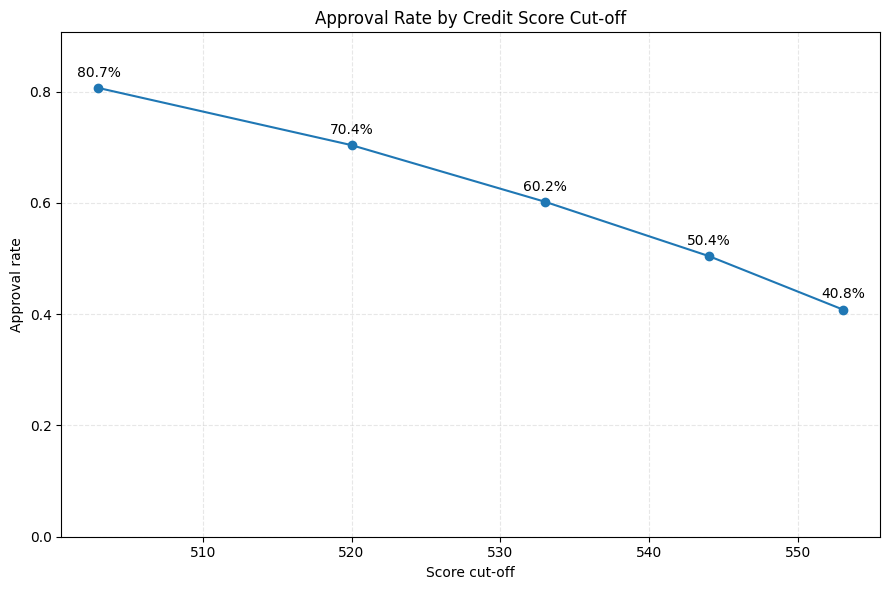

In [55]:
# ============================================================
# APPROVAL RATE THEO SCORE CUT-OFF
# ============================================================

plot_cutoff_data = (
    candidate_cutoff_table
    .sort_values(
        "Score cut-off"
    )
)

plt.figure(figsize=(9, 6))

plt.plot(
    plot_cutoff_data["Score cut-off"],
    plot_cutoff_data["Approval rate"],
    marker="o",
)

for _, row in plot_cutoff_data.iterrows():
    plt.annotate(
        f"{row['Approval rate']:.1%}",
        (
            row["Score cut-off"],
            row["Approval rate"],
        ),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
    )

plt.xlabel("Score cut-off")
plt.ylabel("Approval rate")
plt.title(
    "Approval Rate by Credit Score Cut-off"
)

plt.ylim(
    0,
    min(
        1.05,
        plot_cutoff_data[
            "Approval rate"
        ].max() + 0.10,
    ),
)

plt.grid(
    linestyle="--",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

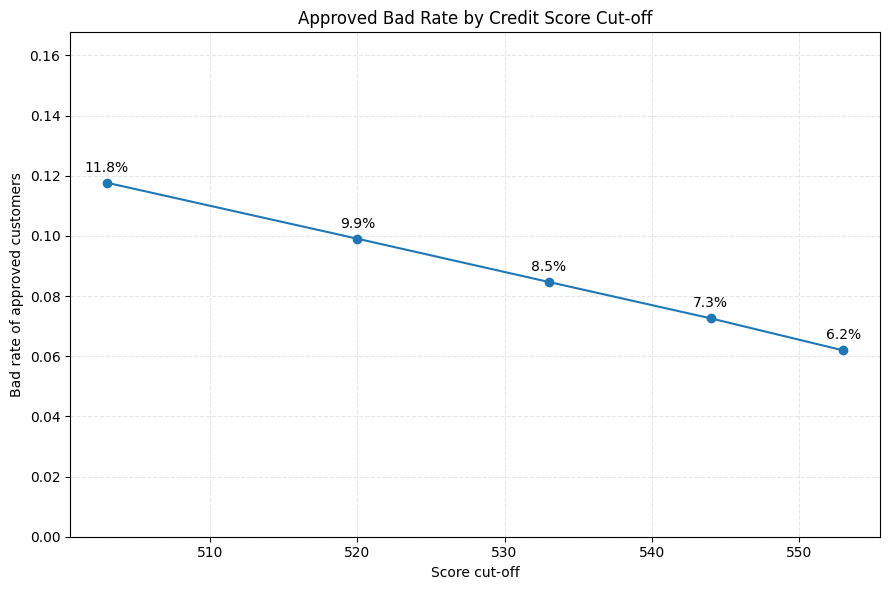

In [56]:
# ============================================================
# APPROVED BAD RATE THEO SCORE CUT-OFF
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    plot_cutoff_data["Score cut-off"],
    plot_cutoff_data["Approved bad rate"],
    marker="o",
)

for _, row in plot_cutoff_data.iterrows():
    plt.annotate(
        f"{row['Approved bad rate']:.1%}",
        (
            row["Score cut-off"],
            row["Approved bad rate"],
        ),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
    )

plt.xlabel("Score cut-off")
plt.ylabel("Bad rate of approved customers")
plt.title(
    "Approved Bad Rate by Credit Score Cut-off"
)

plt.ylim(
    0,
    plot_cutoff_data[
        "Approved bad rate"
    ].max() + 0.05,
)

plt.grid(
    linestyle="--",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

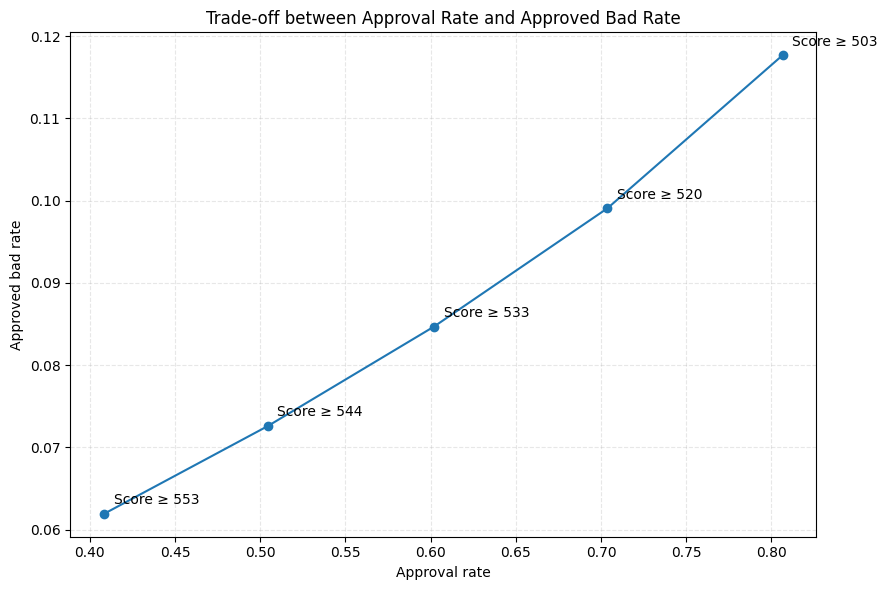

In [57]:
# ============================================================
# APPROVAL RATE VS APPROVED BAD RATE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    plot_cutoff_data["Approval rate"],
    plot_cutoff_data["Approved bad rate"],
    marker="o",
)

for _, row in plot_cutoff_data.iterrows():
    plt.annotate(
        f"Score ≥ {row['Score cut-off']:.0f}",
        (
            row["Approval rate"],
            row["Approved bad rate"],
        ),
        textcoords="offset points",
        xytext=(7, 7),
    )

plt.xlabel("Approval rate")
plt.ylabel("Approved bad rate")
plt.title(
    "Trade-off between Approval Rate and Approved Bad Rate"
)

plt.grid(
    linestyle="--",
    alpha=0.3,
)

plt.tight_layout()
plt.show()


## Lựa chọn Approval Cut-off

Kết quả score bands cho thấy bad rate tăng rõ rệt khi Credit Score
giảm.

Các vùng rủi ro chính là:

```text
Score ≥ 533
→ nhóm rủi ro thấp hơn

503 ≤ Score < 533
→ nhóm rủi ro trung gian

Score < 503
→ nhóm rủi ro cao
```

Từ bảng score band trên tập test, nếu phê duyệt các khách hàng có
score từ 533 trở lên, approval rate xấp xỉ 60% và bad rate của toàn
bộ nhóm được duyệt xấp xỉ 8.3%.

Khi hạ cut-off xuống 520, approval rate tăng lên khoảng 70%, nhưng
approved bad rate cũng tăng lên khoảng 9.6%. Ngoài ra, band từ 503
đến 520 có bad rate riêng khoảng 25%, cho thấy việc tiếp tục hạ
cut-off làm tăng rủi ro đáng kể.

Vì vậy, chính sách sơ bộ được đề xuất là:

```text
Score ≥ 533
→ Auto Approve

503 ≤ Score < 533
→ Manual Review

Score < 503
→ Reject
```



Approval rate tối thiểu: 55%

Bad rate của nhóm được duyệt tối đa: 9%

In [38]:
MIN_APPROVAL_RATE = 0.55
MAX_APPROVED_BAD_RATE = 0.09

eligible_cutoffs = (
    cutoff_table.loc[
        (
            cutoff_table[
                "Approval rate"
            ] >= MIN_APPROVAL_RATE
        )
        & (
            cutoff_table[
                "Approved bad rate"
            ] <= MAX_APPROVED_BAD_RATE
        )
    ]
    .copy()
)

if eligible_cutoffs.empty:
    print(
        "Không có cut-off nào đồng thời thỏa "
        "approval rate và approved bad rate."
    )

    selected_cutoff = None

else:
    # Trong các ngưỡng đạt yêu cầu,
    # chọn ngưỡng có approval rate cao nhất.
    selected_cutoff = (
        eligible_cutoffs
        .sort_values(
            [
                "Approval rate",
                "Approved bad rate",
            ],
            ascending=[
                False,
                True,
            ],
        )
        .iloc[0]
    )

    display(
        selected_cutoff
        .to_frame(
            name="Selected value"
        )
        .style.format({
            "Selected value": (
                lambda value:
                f"{value:.2%}"
                if isinstance(
                    value,
                    (float, np.floating),
                )
                and value <= 1
                else f"{value:.2f}"
            )
        })
    )

,Selected value
Score cut-off,529.00
Approval count,16171.00
Approval rate,63.81%
Approved bad count,1448.00
Approved bad rate,8.95%
Rejected count,9172.00
Rejected bad rate,43.74%
Bad capture rate,73.48%
Good rejection rate,25.95%


## Giải thích ngưỡng tối ưu theo Youden Index

Youden Index được sử dụng để xác định statistical cut-off tạo ra sự
cân bằng tốt nhất giữa Sensitivity và Specificity.

Tại ngưỡng \(c\), Youden Index được tính bởi:

$$
J(c)
=
Sensitivity(c)
+
Specificity(c)
-
1.
$$

Do:

$$
FPR(c)
=
1-Specificity(c),
$$

nên công thức trên tương đương với:

$$
J(c)
=
TPR(c)-FPR(c).
$$

Ngưỡng tối ưu là:

$$
c^*
=
\arg\max_c J(c).
$$

Trong bài toán hiện tại, Default được quy ước là lớp dương. Vì vậy:

$$
Sensitivity
=
\frac{TP}{TP+FN}
$$

đo tỷ lệ khách hàng Default được phát hiện đúng, còn:

$$
Specificity
=
\frac{TN}{TN+FP}
$$

đo tỷ lệ khách hàng Non-default được nhận diện đúng.

Khi giảm PD cut-off, nhiều khách hàng bị phân loại là Default hơn.
Sensitivity thường tăng nhưng Specificity giảm. Khi tăng PD cut-off,
Specificity thường tăng nhưng Sensitivity giảm.

Youden Index lựa chọn ngưỡng làm tổng Sensitivity và Specificity lớn
nhất. Trên ROC curve, đây là điểm có khoảng cách thẳng đứng lớn nhất
so với đường chéo của bộ phân loại ngẫu nhiên.

Quy tắc phân loại tại ngưỡng tối ưu là:

```text
PD ≥ optimal PD cut-off
→ dự báo Default

PD < optimal PD cut-off
→ dự báo Non-default
```

Ngưỡng PD được chuyển sang Credit Score bằng:

$$
Score_{\mathrm{cutoff}}
=
Offset
-
Factor
\ln
\left(
\frac{PD_{\mathrm{cutoff}}}
{1-PD_{\mathrm{cutoff}}}
\right).
$$

Do Credit Score ngược chiều với PD:

```text
PD ≥ optimal PD cut-off
↔ Score ≤ equivalent score cut-off
↔ dự báo Default
```

Ngưỡng Youden được lựa chọn bằng out-of-fold predictions của tập
train. Sau khi được khóa, ngưỡng này được áp dụng nguyên vẹn lên tập
test để đánh giá khả năng tổng quát hóa.

Youden cut-off là statistical benchmark, không nhất thiết là approval
cut-off chính thức. Phương pháp này xem Sensitivity và Specificity có
tầm quan trọng tương đương, nhưng chưa xét đến chi phí duyệt nhầm
khách hàng Default, chi phí từ chối khách hàng Good, expected loss,
approval rate và risk appetite.

In [41]:
# ============================================================
# TÌM STATISTICAL CUT-OFF THEO YOUDEN INDEX
# ============================================================

oof_fpr, oof_tpr, oof_thresholds = roc_curve(
    y_oof,
    oof_probability,
)

oof_auc = roc_auc_score(
    y_oof,
    oof_probability,
)

# roc_curve có thể trả về threshold = inf tại vị trí đầu tiên
finite_threshold_mask = np.isfinite(
    oof_thresholds
)

finite_positions = np.flatnonzero(
    finite_threshold_mask
)

youden_values = (
    oof_tpr[finite_threshold_mask]
    - oof_fpr[finite_threshold_mask]
)

best_finite_position = int(
    np.argmax(youden_values)
)

best_roc_position = int(
    finite_positions[best_finite_position]
)

optimal_youden = float(
    oof_tpr[best_roc_position]
    - oof_fpr[best_roc_position]
)

optimal_pd_cutoff = float(
    oof_thresholds[best_roc_position]
)

optimal_sensitivity = float(
    oof_tpr[best_roc_position]
)

optimal_specificity = float(
    1 - oof_fpr[best_roc_position]
)

# Chuyển PD cut-off sang Credit Score cut-off
optimal_score_cutoff = float(
    OFFSET
    - FACTOR
    * np.log(
        optimal_pd_cutoff
        / (1 - optimal_pd_cutoff)
    )
)

optimal_threshold_summary = pd.DataFrame([{
    "Selection sample": "OOF train",
    "Method": "Maximum Youden Index",
    "OOF AUC": oof_auc,
    "Optimal PD cut-off": optimal_pd_cutoff,
    "Equivalent score cut-off": optimal_score_cutoff,
    "Sensitivity": optimal_sensitivity,
    "Specificity": optimal_specificity,
    "Youden Index": optimal_youden,
}])

display(
    optimal_threshold_summary.style.format({
        "OOF AUC": "{:.5f}",
        "Optimal PD cut-off": "{:.5f}",
        "Equivalent score cut-off": "{:.2f}",
        "Sensitivity": "{:.2%}",
        "Specificity": "{:.2%}",
        "Youden Index": "{:.5f}",
    })
)

,Selection sample,Method,OOF AUC,Optimal PD cut-off,Equivalent score cut-off,Sensitivity,Specificity,Youden Index
0,OOF train,Maximum Youden Index,0.82573,0.25341,518.30,66.83%,81.99%,0.48821


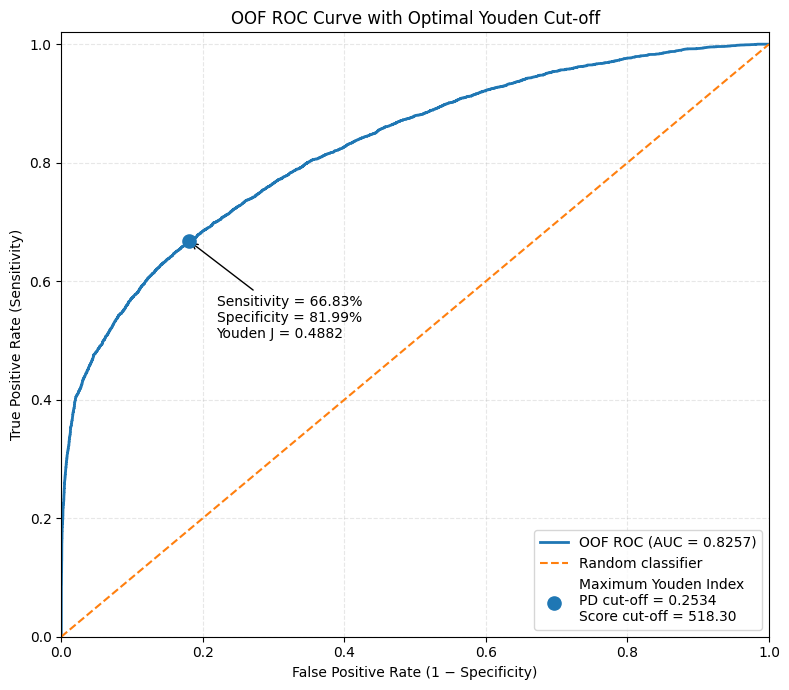

In [42]:
# ============================================================
# ROC CURVE VÀ ĐIỂM CẮT TỐI ƯU
# ============================================================

plt.figure(figsize=(8, 7))

plt.plot(
    oof_fpr,
    oof_tpr,
    linewidth=2,
    label=f"OOF ROC (AUC = {oof_auc:.4f})",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier",
)

plt.scatter(
    oof_fpr[best_roc_position],
    oof_tpr[best_roc_position],
    s=90,
    zorder=5,
    label=(
        "Maximum Youden Index\n"
        f"PD cut-off = {optimal_pd_cutoff:.4f}\n"
        f"Score cut-off = {optimal_score_cutoff:.2f}"
    ),
)

plt.annotate(
    (
        f"Sensitivity = {optimal_sensitivity:.2%}\n"
        f"Specificity = {optimal_specificity:.2%}\n"
        f"Youden J = {optimal_youden:.4f}"
    ),
    xy=(
        oof_fpr[best_roc_position],
        oof_tpr[best_roc_position],
    ),
    xytext=(20, -70),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->"
    },
)

plt.xlabel(
    "False Positive Rate (1 − Specificity)"
)

plt.ylabel(
    "True Positive Rate (Sensitivity)"
)

plt.title(
    "OOF ROC Curve with Optimal Youden Cut-off"
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.grid(
    linestyle="--",
    alpha=0.3,
)
plt.legend(
    loc="lower right"
)
plt.tight_layout()
plt.show()

## Nhận xét ROC và Statistical Cut-off

ROC curve được xây dựng từ out-of-fold predictions của tập train.

Diện tích dưới đường cong ROC phản ánh khả năng mô hình xếp một khách hàng Default có mức PD cao hơn một khách hàng Non-default.

Điểm được đánh dấu trên ROC là ngưỡng làm Youden Index lớn nhất:

$$
J_{\max}
=
\max_c
\left[
Sensitivity(c)+Specificity(c)-1
\right].
$$

Tại ngưỡng này, mô hình đạt sự cân bằng thống kê giữa khả năng phát hiện khách hàng Default và khả năng nhận diện khách hàng Non-default.

Ngưỡng PD được chuyển sang ngưỡng Credit Score bằng:

$$
Score_{\mathrm{cutoff}}
=
Offset
-
Factor
\ln
\left(
\frac{PD_{\mathrm{cutoff}}}
{1-PD_{\mathrm{cutoff}}}
\right).
$$

Do Credit Score ngược chiều với PD:

```text
PD ≥ optimal PD cut-off
↔
Score < equivalent score cut-off
↔
Dự báo Default
```

Ngưỡng trên được sử dụng như statistical benchmark. Việc chọn approval cut-off chính thức vẫn cần xem xét approval rate, approved bad rate, expected loss, lợi nhuận kỳ vọng và risk appetite.

In [43]:
# ============================================================
# OOF CONFUSION MATRIX TẠI NGƯỠNG YOUDEN
# ============================================================

oof_predicted_default = (
    oof_probability
    >= optimal_pd_cutoff
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_oof,
    oof_predicted_default,
).ravel()

oof_accuracy = (
    (tp + tn)
    / (tp + tn + fp + fn)
)

oof_precision = (
    tp / (tp + fp)
    if (tp + fp) > 0
    else np.nan
)

oof_recall = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else np.nan
)

oof_specificity_check = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else np.nan
)

oof_f1 = (
    2
    * oof_precision
    * oof_recall
    / (oof_precision + oof_recall)
    if (
        np.isfinite(oof_precision)
        and np.isfinite(oof_recall)
        and (oof_precision + oof_recall) > 0
    )
    else np.nan
)

optimal_cutoff_metrics = pd.DataFrame([{
    "PD cut-off": optimal_pd_cutoff,
    "Score cut-off": optimal_score_cutoff,
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp,
    "Accuracy": oof_accuracy,
    "Precision": oof_precision,
    "Sensitivity / Recall": oof_recall,
    "Specificity": oof_specificity_check,
    "F1-score": oof_f1,
}])

display(
    optimal_cutoff_metrics.style.format({
        "PD cut-off": "{:.5f}",
        "Score cut-off": "{:.2f}",
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Sensitivity / Recall": "{:.2%}",
        "Specificity": "{:.2%}",
        "F1-score": "{:.4f}",
    })
)

,PD cut-off,Score cut-off,TN,FP,FN,TP,Accuracy,Precision,Sensitivity / Recall,Specificity,F1-score
0,0.25341,518.30,16302,3581,1811,3649,78.72%,50.47%,66.83%,81.99%,0.5751


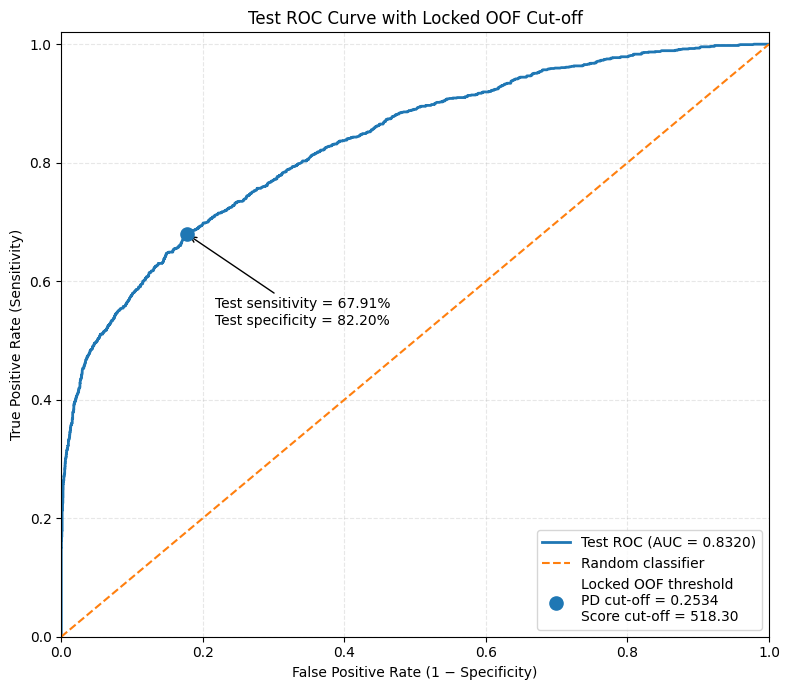

In [44]:
# ============================================================
# TEST ROC VỚI NGƯỠNG ĐÃ BIẾT TỪ OOF TRAIN
# ============================================================

y_test_array = np.asarray(
    y_test_final,
    dtype=int,
)

test_probability_array = np.asarray(
    test_probability,
    dtype=float,
)

test_fpr_curve, test_tpr_curve, _ = roc_curve(
    y_test_array,
    test_probability_array,
)

test_auc_locked = roc_auc_score(
    y_test_array,
    test_probability_array,
)

test_predicted_default = (
    test_probability_array
    >= optimal_pd_cutoff
).astype(int)

test_tn, test_fp, test_fn, test_tp = confusion_matrix(
    y_test_array,
    test_predicted_default,
).ravel()

test_sensitivity_locked = (
    test_tp / (test_tp + test_fn)
)

test_specificity_locked = (
    test_tn / (test_tn + test_fp)
)

test_fpr_locked = (
    1 - test_specificity_locked
)

plt.figure(figsize=(8, 7))

plt.plot(
    test_fpr_curve,
    test_tpr_curve,
    linewidth=2,
    label=f"Test ROC (AUC = {test_auc_locked:.4f})",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier",
)

plt.scatter(
    test_fpr_locked,
    test_sensitivity_locked,
    s=90,
    zorder=5,
    label=(
        "Locked OOF threshold\n"
        f"PD cut-off = {optimal_pd_cutoff:.4f}\n"
        f"Score cut-off = {optimal_score_cutoff:.2f}"
    ),
)

plt.annotate(
    (
        f"Test sensitivity = "
        f"{test_sensitivity_locked:.2%}\n"
        f"Test specificity = "
        f"{test_specificity_locked:.2%}"
    ),
    xy=(
        test_fpr_locked,
        test_sensitivity_locked,
    ),
    xytext=(20, -65),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->"
    },
)

plt.xlabel(
    "False Positive Rate (1 − Specificity)"
)

plt.ylabel(
    "True Positive Rate (Sensitivity)"
)

plt.title(
    "Test ROC Curve with Locked OOF Cut-off"
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.grid(
    linestyle="--",
    alpha=0.3,
)
plt.legend(
    loc="lower right"
)
plt.tight_layout()
plt.show()

# Further reading

## Calibration
Calibration đánh giá mức độ phù hợp giữa xác suất default do mô hình
dự báo và tỷ lệ default thực tế.

Một mô hình được calibration tốt khi một nhóm khách hàng có PD trung
bình bằng 20% cũng có tỷ lệ default thực tế xấp xỉ 20%.

Calibration khác với discrimination:

- AUC, Gini và KS đánh giá khả năng xếp hạng khách hàng.
- Calibration đánh giá độ chính xác của giá trị xác suất dự báo.

Mô hình calibration được biểu diễn bởi:

$$
\operatorname{logit}
\left[
P(Y=1)
\right]
=
a+
b\operatorname{logit}
\left(
\hat p
\right),
$$

trong đó:

- a là calibration intercept;
- b là calibration slope;
- $\hat p$ là PD do mô hình dự báo.

Trạng thái lý tưởng là:

$$
a=0,
\qquad
b=1.
$$

Mô hình cuối cùng có:

$$
Calibration\ intercept=0.0357,
$$

và:

$$
Calibration\ slope=1.0386.
$$

Calibration intercept rất gần 0, cho thấy mô hình không có xu hướng
dự báo PD quá cao hoặc quá thấp trên toàn bộ danh mục. Giá trị dương
nhỏ cho thấy mô hình có xu hướng đánh giá thấp rủi ro tổng thể một
lượng không đáng kể.

Calibration slope rất gần 1, cho thấy mức phân tán của xác suất dự
báo phù hợp với mức phân tán của rủi ro thực tế. Slope lớn hơn 1 một
chút cho thấy xác suất dự báo có thể hơi bị nén về giá trị trung
bình, nhưng mức sai lệch nhỏ.

Calibration table cho thấy nhóm rủi ro thấp nhất có PD dự báo trung
bình 1.94% và bad rate thực tế 1.89%, thể hiện calibration rất tốt.

Ở một số nhóm PD thấp, bad rate thực tế cao hơn PD dự báo từ khoảng
0.4 đến 2.0 điểm phần trăm. Điều này cho thấy mô hình hơi đánh giá
thấp rủi ro tại phần thấp của phân phối.

Ở các nhóm có PD trung bình khoảng 20.36%, 29.50% và 45.89%, bad
rate thực tế lần lượt là 17.22%, 25.04% và 38.29%. Mô hình đánh giá
rủi ro cao hơn thực tế tại các nhóm này.

Ở nhóm rủi ro cao nhất, PD dự báo trung bình là 76.36%, trong khi bad
rate thực tế là 85.17%. Mô hình đánh giá thấp rủi ro khoảng 8.81
điểm phần trăm tại phần đuôi rủi ro cao.

Vì vậy, mô hình có calibration tổng thể tốt nhưng chưa hoàn hảo tại
mọi vùng PD. Intercept và slope gần giá trị lý tưởng, trong khi
calibration table cho thấy một số sai lệch cục bộ tại các nhóm rủi
ro trung bình cao và nhóm rủi ro cao nhất.

Mô hình được chấp nhận cho bước chuyển PD thành Credit Score. Tuy
nhiên, không thực hiện recalibration trên tập test, vì test được giữ
làm tập đánh giá ngoài mẫu cuối cùng. Trong triển khai thực tế,
calibration cần tiếp tục được kiểm tra trên dữ liệu out-of-time hoặc
dữ liệu vận hành mới.